# 阶段 0：数据准备 - 构建价格因子 + 市值过滤

In [1]:
import pandas as pd
import numpy as np

# ==========================================
# 模块 NEW: 从 CRSP 构建价格/交易量因子 + 市值过滤
# 【替换你原来的 Cell 6】
# ==========================================

print(">>> 1. 正在读取底层数据...")
df_panel = pd.read_csv('final_master_panel.csv')
df_price = pd.read_csv('price.csv', low_memory=False)

# --- 统一格式 ---
df_price.rename(columns={'PERMNO': 'permno'}, inplace=True)
df_price['date'] = pd.to_datetime(df_price['date'])
df_price['PRC'] = pd.to_numeric(df_price['PRC'], errors='coerce').abs()
df_price['SHROUT'] = pd.to_numeric(df_price['SHROUT'], errors='coerce')
df_price['RET'] = pd.to_numeric(df_price['RET'], errors='coerce')
df_price['VOL'] = pd.to_numeric(df_price['VOL'], errors='coerce')

df_price['market_cap'] = df_price['PRC'] * df_price['SHROUT']
df_price['year_month'] = df_price['date'].dt.to_period('M')
df_price = df_price.sort_values(['permno', 'date']).reset_index(drop=True)

# ==========================================
# 2. 逐月聚合
# ==========================================
print(">>> 2. 正在构建价格/交易量因子 (按月聚合)...")

monthly = df_price.groupby(['permno', 'year_month']).agg(
    monthly_ret   = ('RET', lambda x: (1 + x.dropna()).prod() - 1),
    monthly_vol   = ('RET', lambda x: x.dropna().std()),
    avg_volume    = ('VOL', 'mean'),
    avg_shrout    = ('SHROUT', 'mean'),
    month_end_cap = ('market_cap', 'last'),
    trading_days  = ('RET', 'count'),
).reset_index()

monthly = monthly.sort_values(['permno', 'year_month']).reset_index(drop=True)

# ==========================================
# 3. 用循环逐股票构建滚动因子 (避免 groupby.apply 的兼容性问题)
# ==========================================
print(">>> 3. 正在构建动量/反转/波动率/流动性因子 (逐股票处理)...")

results = []
for permno, g in monthly.groupby('permno'):
    g = g.copy()
    
    # 因子 1: 动量 (t-12 到 t-2 的累计收益)
    g['mom_12_1'] = g['monthly_ret'].shift(1).rolling(11, min_periods=9).apply(
        lambda x: (1 + x).prod() - 1, raw=False
    )
    
    # 因子 2: 短期反转 (上个月收益率)
    g['reversal_1m'] = g['monthly_ret'].shift(1)
    
    # 因子 3: 波动率 (过去12个月月收益率标准差)
    g['vol_12m'] = g['monthly_ret'].shift(1).rolling(12, min_periods=9).std()
    
    # 因子 4: 换手率
    g['turnover'] = (g['avg_volume'] / g['avg_shrout'].replace(0, np.nan)).shift(1)
    
    # 因子 5: Amihud 非流动性
    g['amihud_illiq'] = (g['monthly_ret'].abs() / (g['avg_volume'] * g['month_end_cap']).replace(0, np.nan)).shift(1)
    
    # 因子 6: Log 市值
    g['log_mcap'] = np.log(g['month_end_cap'].replace(0, np.nan)).shift(1)
    
    results.append(g)

monthly = pd.concat(results, ignore_index=True)

print(f">>> 因子构建完成，验证列: {monthly.columns.tolist()}")

# 只保留合并需要的列
new_factor_cols = ['mom_12_1', 'reversal_1m', 'vol_12m', 'turnover', 'amihud_illiq', 'log_mcap']
monthly_factors = monthly[['permno', 'year_month', 'month_end_cap'] + new_factor_cols].copy()

# ==========================================
# 4. 合并到主面板 & 市值过滤
# ==========================================
print(">>> 4. 将新因子合并到特征面板...")
df_panel['public_date'] = pd.to_datetime(df_panel['public_date'])
df_panel['year_month'] = df_panel['public_date'].dt.to_period('M')

df_merged = pd.merge(df_panel, monthly_factors, on=['permno', 'year_month'], how='inner')

print(">>> 5. 执行截面过滤：每月砍掉市值最小的 30% 股票...")
def filter_bottom_30(group):
    threshold = group['month_end_cap'].quantile(0.30)
    return group[group['month_end_cap'] >= threshold]

df_filtered = df_merged.groupby('year_month', group_keys=False).apply(filter_bottom_30)

# 清理辅助列
df_filtered = df_filtered.drop(columns=['year_month', 'month_end_cap'], errors='ignore')

# 保存
df_filtered.to_csv('final_master_panel_large_caps.csv', index=False)

print("\n==========================================")
print(f"构建完成！")
print(f"原始面板: {len(df_panel)} 行")
print(f"合并后:   {len(df_merged)} 行")
print(f"过滤后:   {len(df_filtered)} 行")
print(f"新增因子: {new_factor_cols}")
print(f"现在总特征数: 45 (原有) + {len(new_factor_cols)} (新增) = {45 + len(new_factor_cols)}")
print("==========================================")

>>> 1. 正在读取底层数据...
>>> 2. 正在构建价格/交易量因子 (按月聚合)...
>>> 3. 正在构建动量/反转/波动率/流动性因子 (逐股票处理)...
>>> 因子构建完成，验证列: ['permno', 'year_month', 'monthly_ret', 'monthly_vol', 'avg_volume', 'avg_shrout', 'month_end_cap', 'trading_days', 'mom_12_1', 'reversal_1m', 'vol_12m', 'turnover', 'amihud_illiq', 'log_mcap']
>>> 4. 将新因子合并到特征面板...
>>> 5. 执行截面过滤：每月砍掉市值最小的 30% 股票...

构建完成！
原始面板: 474290 行
合并后:   474290 行
过滤后:   331976 行
新增因子: ['mom_12_1', 'reversal_1m', 'vol_12m', 'turnover', 'amihud_illiq', 'log_mcap']
现在总特征数: 45 (原有) + 6 (新增) = 51


# 阶段 1：基线模型 - 回归 (全部51个特征)
用 RandomForestRegressor 预测 next_month_ret，使用自动识别的全部特征作为基线。

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# 模块 1: 数据读取与环境准备
# ==========================================
print(">>> 正在加载清洗好的底层数据...")
df = pd.read_csv('final_master_panel_large_caps.csv')

# 确保时间格式并按时间、股票代码严格排序
df['public_date'] = pd.to_datetime(df['public_date'])
df = df.sort_values(['public_date', 'permno']).reset_index(drop=True)

# 自动识别特征列 (剔除主键和标签)
exclude_cols = ['permno', 'adate', 'qdate', 'public_date', 'year_month', 'next_month_ret', 'year']
features = [col for col in df.columns if col not in exclude_cols]
target = 'next_month_ret'

print(f">>> 成功加载！共有 {len(features)} 个特征准备入模。")

>>> 正在加载清洗好的底层数据...
>>> 成功加载！共有 51 个特征准备入模。


In [3]:
# ==========================================
# 模块 2: 基于 .loc 的优雅时间切分 (防 WRDS 漏数据版)
# ==========================================
# 【重点1】必须把时间列设为 Index，Pandas 才允许使用 .loc 进行时间切片
df_idx = df.set_index('public_date').sort_index()

all_test_predictions = []
all_valid_predictions = []
feature_importances = np.zeros(len(features))

# 提取所有不重复的“年月”，这样可以彻底避免考虑大月小月和闰年的问题
months = sorted(df_idx.index.to_period('M').unique())

# 窗口参数设置 (单位：月)
train_len = 36  # 训练集：3年
gap_len = 3     # 隔离期：3个月
valid_len = 12  # 验证集：1年
test_len = 12   # 测试集：1年
step = 12       # 每次滚动：1年

print(">>> 开始执行基于 .loc 的 Walk-Forward 训练...\n")

start_i = 0
while True:
    # 1. 计算当前窗口在月份列表里的索引位置
    train_end_i = start_i + train_len
    valid_start_i = train_end_i + gap_len
    valid_end_i = valid_start_i + valid_len
    test_start_i = valid_end_i + gap_len
    test_end_i = test_start_i + test_len
    
    if test_end_i > len(months):
        break
        
    # 2. 生成你想要的 'YYYY-MM' 字符串切片边界
    t_start = str(months[start_i])
    t_end   = str(months[train_end_i - 1])
    
    v_start = str(months[valid_start_i])
    v_end   = str(months[valid_end_i - 1])
    
    te_start = str(months[test_start_i])
    te_end   = str(months[test_end_i - 1])
    
    # 3. 打印出直观的切片范围，方便检查
    print(f"[{te_start} 至 {te_end} 预测轮次]")
    print(f"  ├─ Train: df.loc['{t_start}' : '{t_end}']")
    print(f"  ├─ Valid: df.loc['{v_start}' : '{v_end}']")
    print(f"  └─ Test : df.loc['{te_start}' : '{te_end}']\n")
    
    # 4. 【核心】执行你想要的 .loc 优雅切片
    train_df = df_idx.loc[t_start : t_end]
    valid_df = df_idx.loc[v_start : v_end]
    test_df  = df_idx.loc[te_start : te_end]
    
    X_train, y_train = train_df[features], train_df[target]
    X_valid, y_valid = valid_df[features], valid_df[target]
    X_test,  y_test  = test_df[features],  test_df[target]
    
    # 训练模型
    # 解除封印：树增加到 300 棵，深度放宽到 12，甚至加入 min_samples_leaf 防止极小叶子节点
    rf = RandomForestRegressor(
        n_estimators=300, 
        max_depth=12, 
        min_samples_leaf=20, # 每片叶子至少包含20只股票，防止在干净数据里过拟合
        random_state=42, 
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    # 预测并保存结果
    valid_df_copy = valid_df.copy()
    valid_df_copy['rf_predict_score'] = rf.predict(X_valid)
    all_valid_predictions.append(valid_df_copy)
    
    test_df_copy = test_df.copy()
    test_df_copy['rf_predict_score'] = rf.predict(X_test)
    all_test_predictions.append(test_df_copy)
    
    feature_importances += rf.feature_importances_
    
    # 窗口向前推进一年
    start_i += step

print(">>> 所有滚动窗口训练完毕！")

>>> 开始执行基于 .loc 的 Walk-Forward 训练...

[2016-07 至 2017-06 预测轮次]
  ├─ Train: df.loc['2012-01' : '2014-12']
  ├─ Valid: df.loc['2015-04' : '2016-03']
  └─ Test : df.loc['2016-07' : '2017-06']

[2017-07 至 2018-06 预测轮次]
  ├─ Train: df.loc['2013-01' : '2015-12']
  ├─ Valid: df.loc['2016-04' : '2017-03']
  └─ Test : df.loc['2017-07' : '2018-06']

[2018-07 至 2019-06 预测轮次]
  ├─ Train: df.loc['2014-01' : '2016-12']
  ├─ Valid: df.loc['2017-04' : '2018-03']
  └─ Test : df.loc['2018-07' : '2019-06']

[2019-07 至 2020-06 预测轮次]
  ├─ Train: df.loc['2015-01' : '2017-12']
  ├─ Valid: df.loc['2018-04' : '2019-03']
  └─ Test : df.loc['2019-07' : '2020-06']

[2020-07 至 2021-06 预测轮次]
  ├─ Train: df.loc['2016-01' : '2018-12']
  ├─ Valid: df.loc['2019-04' : '2020-03']
  └─ Test : df.loc['2020-07' : '2021-06']

[2021-07 至 2022-06 预测轮次]
  ├─ Train: df.loc['2017-01' : '2019-12']
  ├─ Valid: df.loc['2020-04' : '2021-03']
  └─ Test : df.loc['2021-07' : '2022-06']

>>> 所有滚动窗口训练完毕！


In [4]:
import pandas as pd

# 1. 计算总共跑了多少个滚动窗口
total_runs = len(all_test_predictions)
# 2. 计算平均特征重要性
avg_importances = feature_importances / total_runs

# 3. 将特征和分数打包成表格
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance_Score': avg_importances
})

# 4. 按重要性从高到低排序，并加上排名
importance_df = importance_df.sort_values(by='Importance_Score', ascending=False).reset_index(drop=True)
importance_df['Rank'] = importance_df.index + 1

# 把分数格式化为保留4位小数，方便阅读
importance_df['Importance_Score'] = importance_df['Importance_Score'].apply(lambda x: f"{x:.4f}")

# 调整列的展示顺序
importance_df = importance_df[['Rank', 'Feature', 'Importance_Score']]

print("==========================================")
print("     揭晓谜底：Top 20 核心驱动因子     ")
print("==========================================")
# 优雅地展示前 20 名表格
display(importance_df.head(20))

     揭晓谜底：Top 20 核心驱动因子     


,Rank,Feature,Importance_Score
0,1,mom_12_1,0.0839
1,2,reversal_1m,0.0688
2,3,vol_12m,0.0484
3,4,ps,0.0377
4,5,turnover,0.0362
5,6,log_mcap,0.0306
6,7,pcf,0.0291
7,8,bm,0.0289
8,9,ptb,0.0287
9,10,GProf,0.0266


In [5]:
# 1. 重新拼接，并使用 reset_index() 把索引里的 public_date 释放回普通列
df_final_test = pd.concat(all_test_predictions).reset_index()

# 2. 重新覆盖保存 CSV
df_final_test.to_csv('rf_test_predictions_large.csv', index=False)
print("抢救成功！public_date 已经回到文件里了。")

抢救成功！public_date 已经回到文件里了。


正在加载测试集预测结果...

=== 策略 vs Buy & Hold (基准) 核心指标对比 ===
[你的 RF 策略] 年化收益: 7.41% | 波动率: 29.93% | 夏普: 0.25
[全市场基准]   年化收益: 11.32% | 波动率: 21.52% | 夏普: 0.53


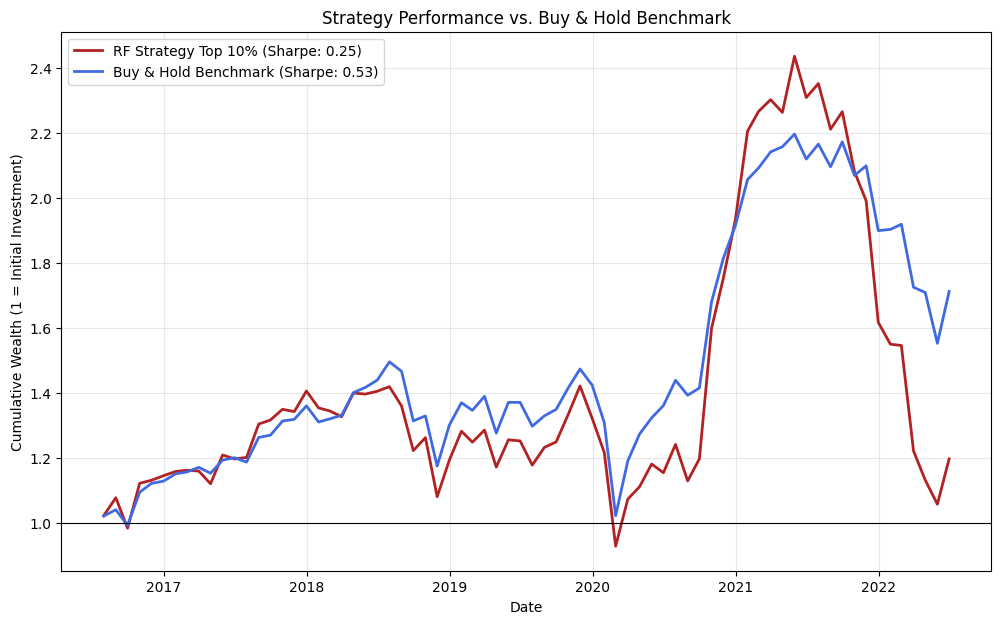

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取预测结果
print("正在加载测试集预测结果...")
df_test = pd.read_csv('rf_test_predictions_large.csv')
df_test['public_date'] = pd.to_datetime(df_test['public_date'])

# 2. 计算策略收益 (Long Top 10%)
def get_decile(x):
    return pd.qcut(x, 10, labels=False, duplicates='drop') + 1

df_test['Decile'] = df_test.groupby('public_date')['rf_predict_score'].transform(get_decile)
long_portfolio = df_test[df_test['Decile'] == 10].copy()

# 策略每月收益
port_ret = long_portfolio.groupby('public_date')['next_month_ret'].mean().reset_index()
port_ret.rename(columns={'next_month_ret': 'Strategy_Return'}, inplace=True)

# 3. 【新增】计算 Buy & Hold 基准收益 (全市场等权)
# 逻辑：不做任何预测筛选，直接把当月所有股票的收益率取平均，模拟“买下整个市场并持有”
benchmark_ret = df_test.groupby('public_date')['next_month_ret'].mean().reset_index()
benchmark_ret.rename(columns={'next_month_ret': 'Benchmark_Return'}, inplace=True)

# 将基准收益合并到策略结果表中
port_ret = pd.merge(port_ret, benchmark_ret, on='public_date')

# 4. 扣除交易成本 (策略需要换手扣 10bps，基准假设一直持有不扣费)
cost_bps = 10 
monthly_cost = (cost_bps * 2) / 10000 
port_ret['Strategy_Net_10bps'] = port_ret['Strategy_Return'] - monthly_cost

# 5. 计算累计净值
port_ret['Cum_Strategy_Net'] = (1 + port_ret['Strategy_Net_10bps']).cumprod()
port_ret['Cum_Benchmark'] = (1 + port_ret['Benchmark_Return']).cumprod()

# 6. 计算核心指标对比
def calc_metrics(ret_series):
    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol
    return ann_ret, ann_vol, sharpe

strat_ret, strat_vol, strat_sharpe = calc_metrics(port_ret['Strategy_Net_10bps'])
bench_ret, bench_vol, bench_sharpe = calc_metrics(port_ret['Benchmark_Return'])

print(f"\n=== 策略 vs Buy & Hold (基准) 核心指标对比 ===")
print(f"[你的 RF 策略] 年化收益: {strat_ret:.2f}% | 波动率: {strat_vol:.2f}% | 夏普: {strat_sharpe:.2f}")
print(f"[全市场基准]   年化收益: {bench_ret:.2f}% | 波动率: {bench_vol:.2f}% | 夏普: {bench_sharpe:.2f}")

# 7. 画出双线对比图
plt.figure(figsize=(12, 7))
# 你的策略曲线 (红色)
plt.plot(port_ret['public_date'], port_ret['Cum_Strategy_Net'], label=f'RF Strategy Top 10% (Sharpe: {strat_sharpe:.2f})', color='firebrick', linewidth=2)
# Buy & Hold 基准曲线 (蓝色)
plt.plot(port_ret['public_date'], port_ret['Cum_Benchmark'], label=f'Buy & Hold Benchmark (Sharpe: {bench_sharpe:.2f})', color='royalblue', linewidth=2, linestyle='-')

plt.axhline(1, color='black', linewidth=0.8)
plt.title('Strategy Performance vs. Buy & Hold Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (1 = Initial Investment)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

# 阶段 2：特征筛选 - 只保留 Top 20 核心因子
根据阶段1的特征重要性排名，砍掉噪音特征，只保留最核心的20个。

In [7]:
# ==========================================
# 模块 2: 降维打击版 - 基于 Top 20 特征的滚动训练
# ==========================================
# 1. 强制覆盖特征列表：只保留模型认证过的 20 个核心 Alpha 因子
features = [
    'mom_12_1', 'reversal_1m', 'vol_12m', 'ps', 'turnover',
    'log_mcap', 'pcf', 'bm', 'ptb', 'GProf',
    'aftret_invcapx', 'roa', 'pay_turn', 'evm', 'pe_op_basic',
    'CAPEI', 'pe_op_dil', 'roce', 'gpm', 'cash_ratio',
]

print(f">>> 启动特征瘦身：已砍掉噪音特征，仅使用最核心的 {len(features)} 个特征入模...\n")

df_idx = df.set_index('public_date').sort_index()

all_test_predictions = []
all_valid_predictions = []
# 重要性数组的长度现在自动适应这 20 个特征
feature_importances = np.zeros(len(features)) 

months = sorted(df_idx.index.to_period('M').unique())

# 窗口参数
train_len = 36  
gap_len = 3     
valid_len = 12  
test_len = 12   
step = 12       

start_i = 0
while True:
    train_end_i = start_i + train_len
    valid_start_i = train_end_i + gap_len
    valid_end_i = valid_start_i + valid_len
    test_start_i = valid_end_i + gap_len
    test_end_i = test_start_i + test_len
    
    if test_end_i > len(months):
        break
        
    t_start, t_end = str(months[start_i]), str(months[train_end_i - 1])
    v_start, v_end = str(months[valid_start_i]), str(months[valid_end_i - 1])
    te_start, te_end = str(months[test_start_i]), str(months[test_end_i - 1])
    
    train_df = df_idx.loc[t_start : t_end]
    valid_df = df_idx.loc[v_start : v_end]
    test_df  = df_idx.loc[te_start : te_end]
    
    # 这里切分数据时，自动只取这 20 个特征
    X_train, y_train = train_df[features], train_df[target]
    X_valid, y_valid = valid_df[features], valid_df[target]
    X_test,  y_test  = test_df[features],  test_df[target]
    
    # 结合了中等深度和叶子保护的抗过拟合配置
    rf = RandomForestRegressor(
        n_estimators=300, 
        max_depth=8,                # 退一步海阔天空，寻找甜点
        min_samples_leaf=30,        # 强力抗过拟合：每片叶子至少包含30只股票
        random_state=42, 
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    valid_df_copy = valid_df.copy()
    valid_df_copy['rf_predict_score'] = rf.predict(X_valid)
    all_valid_predictions.append(valid_df_copy)
    
    test_df_copy = test_df.copy()
    test_df_copy['rf_predict_score'] = rf.predict(X_test)
    all_test_predictions.append(test_df_copy)
    
    feature_importances += rf.feature_importances_
    
    start_i += step

print(">>> 瘦身版滚动窗口训练完毕！")

>>> 启动特征瘦身：已砍掉噪音特征，仅使用最核心的 20 个特征入模...

>>> 瘦身版滚动窗口训练完毕！


In [8]:
# 1. 重新拼接，并使用 reset_index() 把索引里的 public_date 释放回普通列
df_final_test = pd.concat(all_test_predictions).reset_index()

# 2. 重新覆盖保存 CSV
df_final_test.to_csv('rf_test_predictions_slim.csv', index=False)
print("抢救成功！public_date 已经回到文件里了。")

抢救成功！public_date 已经回到文件里了。


正在加载测试集预测结果...

=== 策略 vs Buy & Hold (基准) 核心指标对比 ===
[你的 RF 策略] 年化收益: 8.69% | 波动率: 29.77% | 夏普: 0.29
[全市场基准]   年化收益: 11.32% | 波动率: 21.52% | 夏普: 0.53


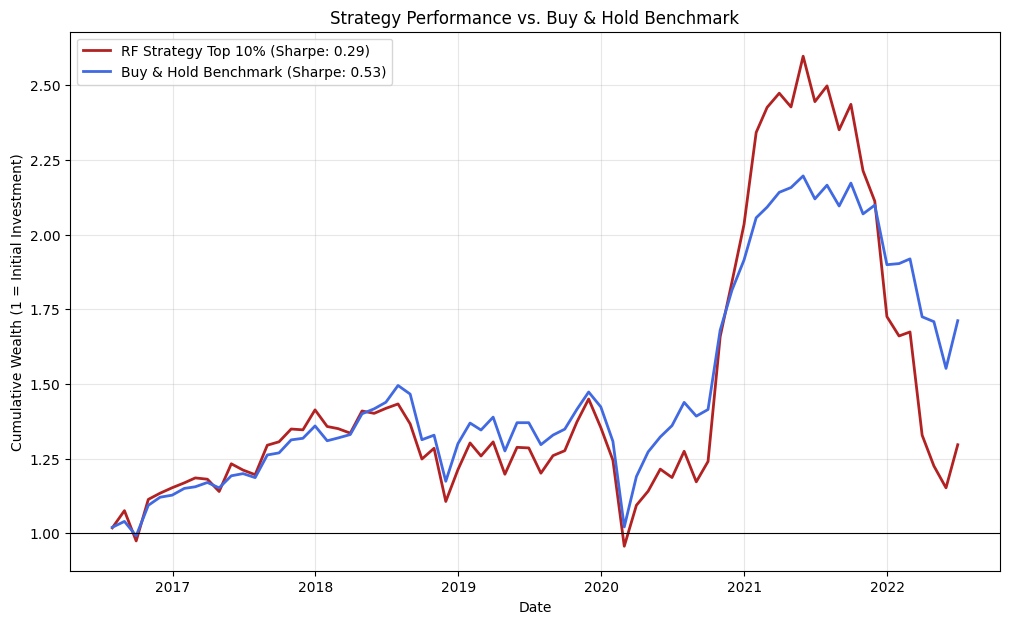

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取预测结果
print("正在加载测试集预测结果...")
df_test = pd.read_csv('rf_test_predictions_slim.csv')
df_test['public_date'] = pd.to_datetime(df_test['public_date'])

# 2. 计算策略收益 (Long Top 10%)
def get_decile(x):
    return pd.qcut(x, 10, labels=False, duplicates='drop') + 1

df_test['Decile'] = df_test.groupby('public_date')['rf_predict_score'].transform(get_decile)
long_portfolio = df_test[df_test['Decile'] == 10].copy()

# 策略每月收益
port_ret = long_portfolio.groupby('public_date')['next_month_ret'].mean().reset_index()
port_ret.rename(columns={'next_month_ret': 'Strategy_Return'}, inplace=True)

# 3. 【新增】计算 Buy & Hold 基准收益 (全市场等权)
# 逻辑：不做任何预测筛选，直接把当月所有股票的收益率取平均，模拟“买下整个市场并持有”
benchmark_ret = df_test.groupby('public_date')['next_month_ret'].mean().reset_index()
benchmark_ret.rename(columns={'next_month_ret': 'Benchmark_Return'}, inplace=True)

# 将基准收益合并到策略结果表中
port_ret = pd.merge(port_ret, benchmark_ret, on='public_date')

# 4. 扣除交易成本 (策略需要换手扣 10bps，基准假设一直持有不扣费)
cost_bps = 10 
monthly_cost = (cost_bps * 2) / 10000 
port_ret['Strategy_Net_10bps'] = port_ret['Strategy_Return'] - monthly_cost

# 5. 计算累计净值
port_ret['Cum_Strategy_Net'] = (1 + port_ret['Strategy_Net_10bps']).cumprod()
port_ret['Cum_Benchmark'] = (1 + port_ret['Benchmark_Return']).cumprod()

# 6. 计算核心指标对比
def calc_metrics(ret_series):
    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol
    return ann_ret, ann_vol, sharpe

strat_ret, strat_vol, strat_sharpe = calc_metrics(port_ret['Strategy_Net_10bps'])
bench_ret, bench_vol, bench_sharpe = calc_metrics(port_ret['Benchmark_Return'])

print(f"\n=== 策略 vs Buy & Hold (基准) 核心指标对比 ===")
print(f"[你的 RF 策略] 年化收益: {strat_ret:.2f}% | 波动率: {strat_vol:.2f}% | 夏普: {strat_sharpe:.2f}")
print(f"[全市场基准]   年化收益: {bench_ret:.2f}% | 波动率: {bench_vol:.2f}% | 夏普: {bench_sharpe:.2f}")

# 7. 画出双线对比图
plt.figure(figsize=(12, 7))
# 你的策略曲线 (红色)
plt.plot(port_ret['public_date'], port_ret['Cum_Strategy_Net'], label=f'RF Strategy Top 10% (Sharpe: {strat_sharpe:.2f})', color='firebrick', linewidth=2)
# Buy & Hold 基准曲线 (蓝色)
plt.plot(port_ret['public_date'], port_ret['Cum_Benchmark'], label=f'Buy & Hold Benchmark (Sharpe: {bench_sharpe:.2f})', color='royalblue', linewidth=2, linestyle='-')

plt.axhline(1, color='black', linewidth=0.8)
plt.title('Strategy Performance vs. Buy & Hold Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (1 = Initial Investment)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

# 阶段 3：超参数调优 - 回归版 Grid Search
用多窗口验证寻找穿越牛熊的稳健参数组合。

In [10]:
# ==========================================
# 终极加分项：跨越牛熊的多窗口 (Multi-Window) 自动调参
# ==========================================
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor

print(">>> 启动多窗口超参数调优 (寻找穿越牛熊的 Robust 参数)...\n")

depth_options = [4, 6, 8, 10, 12, 15, None]  # None 代表不限制深度
leaf_options = [10, 20, 30, 50, 100, 150]            # 每片叶子至少包含30、50或100只股票,

best_params = None
best_valid_error = float('inf')

# 提取3个具有代表性的历史测试锚点 (假设以月为单位)
# 例如：倒数第 84 个月(约7年前), 倒数第 48 个月(约4年前), 倒数第 12 个月(最近1年)
# 这样能覆盖早期、中期和近期的不同市场风格
anchor_points = [-84, -48, -12] 

# 遍历你的参数组合
for d in depth_options:
    for l in leaf_options:
        print(f"正在综合评估参数: max_depth={d}, min_samples_leaf={l}...")
        
        errors = [] # 记录这组参数在不同时期的表现
        
        for anchor in anchor_points:
            # 确保数据足够长，如果早期数据不够就跳过
            if abs(anchor) + 36 > len(months):
                continue
                
            # 动态切分：当前锚点往前推 36 个月作为训练，当前锚点往后 12 个月作为验证
            t_start = str(months[anchor - 36])
            t_end   = str(months[anchor - 1])
            v_start = str(months[anchor])
            # 处理越界问题
            v_end_idx = anchor + 11 if anchor + 11 < 0 else -1
            v_end   = str(months[v_end_idx])
            
            train_df = df_idx.loc[t_start : t_end]
            valid_df = df_idx.loc[v_start : v_end]
            
            X_train, y_train = train_df[features], train_df[target]
            X_valid, y_valid = valid_df[features], valid_df[target]
            
            # 训练并预测
            rf_test = RandomForestRegressor(
                n_estimators=100, 
                max_depth=d, 
                min_samples_leaf=l, 
                max_features='sqrt',
                random_state=42, 
                n_jobs=-1
            )
            rf_test.fit(X_train, y_train)
            
            valid_preds = rf_test.predict(X_valid)
            errors.append(mean_squared_error(y_valid, valid_preds))
        
        # 计算这组参数在 3 个不同时期的【平均误差】
        avg_error = np.mean(errors)
        print(f"  └─ 跨期平均验证误差 (MSE): {avg_error:.6f}")
        
        if avg_error < best_valid_error:
            best_valid_error = avg_error
            best_params = {'max_depth': d, 'min_samples_leaf': l}

print("\n==========================================")
print(f"调优完成！经受住多轮牛熊考验的最佳参数是: {best_params}")
print("==========================================")

>>> 启动多窗口超参数调优 (寻找穿越牛熊的 Robust 参数)...

正在综合评估参数: max_depth=4, min_samples_leaf=10...
  └─ 跨期平均验证误差 (MSE): 0.020802
正在综合评估参数: max_depth=4, min_samples_leaf=20...
  └─ 跨期平均验证误差 (MSE): 0.020804
正在综合评估参数: max_depth=4, min_samples_leaf=30...
  └─ 跨期平均验证误差 (MSE): 0.020813
正在综合评估参数: max_depth=4, min_samples_leaf=50...
  └─ 跨期平均验证误差 (MSE): 0.020808
正在综合评估参数: max_depth=4, min_samples_leaf=100...
  └─ 跨期平均验证误差 (MSE): 0.020799
正在综合评估参数: max_depth=4, min_samples_leaf=150...
  └─ 跨期平均验证误差 (MSE): 0.020800
正在综合评估参数: max_depth=6, min_samples_leaf=10...
  └─ 跨期平均验证误差 (MSE): 0.020858
正在综合评估参数: max_depth=6, min_samples_leaf=20...
  └─ 跨期平均验证误差 (MSE): 0.020854
正在综合评估参数: max_depth=6, min_samples_leaf=30...
  └─ 跨期平均验证误差 (MSE): 0.020874
正在综合评估参数: max_depth=6, min_samples_leaf=50...
  └─ 跨期平均验证误差 (MSE): 0.020855
正在综合评估参数: max_depth=6, min_samples_leaf=100...
  └─ 跨期平均验证误差 (MSE): 0.020848
正在综合评估参数: max_depth=6, min_samples_leaf=150...
  └─ 跨期平均验证误差 (MSE): 0.020846
正在综合评估参数: max_depth=8, min_samples_leaf=10...

In [11]:
# ==========================================
# 模块 2: 降维打击版 - 基于 Top 20 特征的滚动训练
# ==========================================
# 1. 强制覆盖特征列表：只保留模型认证过的 20 个核心 Alpha 因子
features = [
    'mom_12_1', 'reversal_1m', 'vol_12m', 'ps', 'turnover',
    'log_mcap', 'pcf', 'bm', 'ptb', 'GProf',
    'aftret_invcapx', 'roa', 'pay_turn', 'evm', 'pe_op_basic',
    'CAPEI', 'pe_op_dil', 'roce', 'gpm', 'cash_ratio',
]

print(f">>> 启动特征瘦身：已砍掉噪音特征，仅使用最核心的 {len(features)} 个特征入模...\n")

df_idx = df.set_index('public_date').sort_index()

all_test_predictions = []
all_valid_predictions = []
# 重要性数组的长度现在自动适应这 20 个特征
feature_importances = np.zeros(len(features)) 

months = sorted(df_idx.index.to_period('M').unique())

# 窗口参数
train_len = 36  
gap_len = 3     
valid_len = 12  
test_len = 12   
step = 12       

start_i = 0
while True:
    train_end_i = start_i + train_len
    valid_start_i = train_end_i + gap_len
    valid_end_i = valid_start_i + valid_len
    test_start_i = valid_end_i + gap_len
    test_end_i = test_start_i + test_len
    
    if test_end_i > len(months):
        break
        
    t_start, t_end = str(months[start_i]), str(months[train_end_i - 1])
    v_start, v_end = str(months[valid_start_i]), str(months[valid_end_i - 1])
    te_start, te_end = str(months[test_start_i]), str(months[test_end_i - 1])
    
    train_df = df_idx.loc[t_start : t_end]
    valid_df = df_idx.loc[v_start : v_end]
    test_df  = df_idx.loc[te_start : te_end]
    
    # 这里切分数据时，自动只取这 20 个特征
    X_train, y_train = train_df[features], train_df[target]
    X_valid, y_valid = valid_df[features], valid_df[target]
    X_test,  y_test  = test_df[features],  test_df[target]
    
    rf = RandomForestRegressor(
        n_estimators=300, 
        max_depth=4,                # 机器认证的黄金抗噪深度
        min_samples_leaf=100,       # 机器认证的群体保护阈值
        max_features='sqrt',
        random_state=42, 
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    valid_df_copy = valid_df.copy()
    valid_df_copy['rf_predict_score'] = rf.predict(X_valid)
    all_valid_predictions.append(valid_df_copy)
    
    test_df_copy = test_df.copy()
    test_df_copy['rf_predict_score'] = rf.predict(X_test)
    all_test_predictions.append(test_df_copy)
    
    feature_importances += rf.feature_importances_
    
    start_i += step

print(">>> final版滚动窗口训练完毕！")

>>> 启动特征瘦身：已砍掉噪音特征，仅使用最核心的 20 个特征入模...

>>> final版滚动窗口训练完毕！


In [12]:
# 1. 重新拼接，并使用 reset_index() 把索引里的 public_date 释放回普通列
df_final_test = pd.concat(all_test_predictions).reset_index()

# 2. 重新覆盖保存 CSV
df_final_test.to_csv('rf_test_predictions_grid.csv', index=False)
print("抢救成功！public_date 已经回到文件里了。")

抢救成功！public_date 已经回到文件里了。


正在加载测试集预测结果...

=== 策略 vs Buy & Hold (基准) 核心指标对比 ===
[你的 RF 策略] 年化收益: 10.85% | 波动率: 28.48% | 夏普: 0.38
[全市场基准]   年化收益: 11.32% | 波动率: 21.52% | 夏普: 0.53


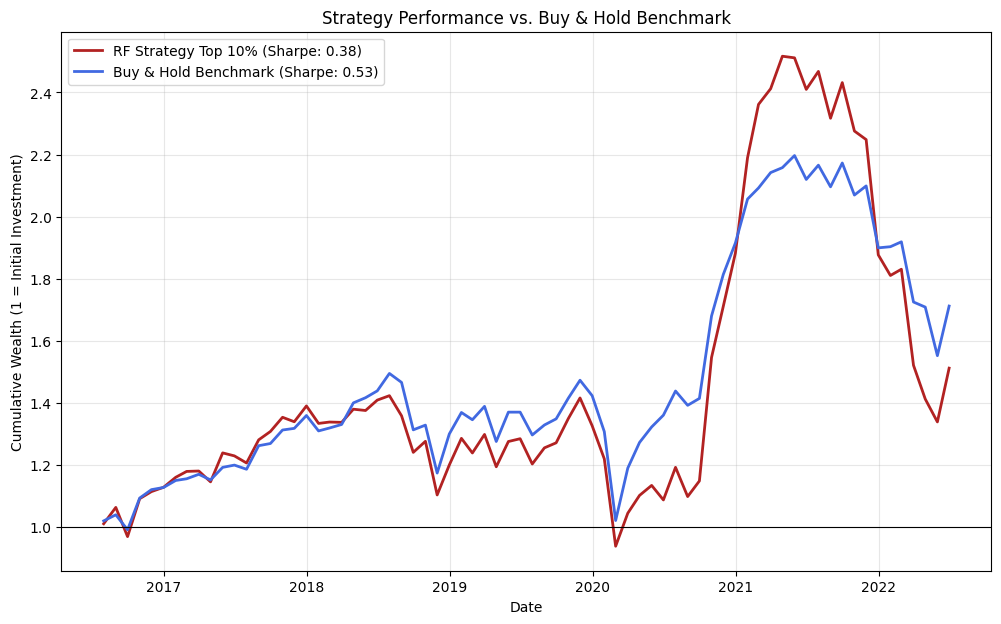

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取预测结果
print("正在加载测试集预测结果...")
df_test = pd.read_csv('rf_test_predictions_grid.csv')
df_test['public_date'] = pd.to_datetime(df_test['public_date'])

# 2. 计算策略收益 (Long Top 10%)
def get_decile(x):
    return pd.qcut(x, 10, labels=False, duplicates='drop') + 1

df_test['Decile'] = df_test.groupby('public_date')['rf_predict_score'].transform(get_decile)
long_portfolio = df_test[df_test['Decile'] == 10].copy()

# 策略每月收益
port_ret = long_portfolio.groupby('public_date')['next_month_ret'].mean().reset_index()
port_ret.rename(columns={'next_month_ret': 'Strategy_Return'}, inplace=True)

# 3. 【新增】计算 Buy & Hold 基准收益 (全市场等权)
# 逻辑：不做任何预测筛选，直接把当月所有股票的收益率取平均，模拟“买下整个市场并持有”
benchmark_ret = df_test.groupby('public_date')['next_month_ret'].mean().reset_index()
benchmark_ret.rename(columns={'next_month_ret': 'Benchmark_Return'}, inplace=True)

# 将基准收益合并到策略结果表中
port_ret = pd.merge(port_ret, benchmark_ret, on='public_date')

# 4. 扣除交易成本 (策略需要换手扣 10bps，基准假设一直持有不扣费)
cost_bps = 10 
monthly_cost = (cost_bps * 2) / 10000 
port_ret['Strategy_Net_10bps'] = port_ret['Strategy_Return'] - monthly_cost

# 5. 计算累计净值
port_ret['Cum_Strategy_Net'] = (1 + port_ret['Strategy_Net_10bps']).cumprod()
port_ret['Cum_Benchmark'] = (1 + port_ret['Benchmark_Return']).cumprod()

# 6. 计算核心指标对比
def calc_metrics(ret_series):
    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol
    return ann_ret, ann_vol, sharpe

strat_ret, strat_vol, strat_sharpe = calc_metrics(port_ret['Strategy_Net_10bps'])
bench_ret, bench_vol, bench_sharpe = calc_metrics(port_ret['Benchmark_Return'])

print(f"\n=== 策略 vs Buy & Hold (基准) 核心指标对比 ===")
print(f"[你的 RF 策略] 年化收益: {strat_ret:.2f}% | 波动率: {strat_vol:.2f}% | 夏普: {strat_sharpe:.2f}")
print(f"[全市场基准]   年化收益: {bench_ret:.2f}% | 波动率: {bench_vol:.2f}% | 夏普: {bench_sharpe:.2f}")

# 7. 画出双线对比图
plt.figure(figsize=(12, 7))
# 你的策略曲线 (红色)
plt.plot(port_ret['public_date'], port_ret['Cum_Strategy_Net'], label=f'RF Strategy Top 10% (Sharpe: {strat_sharpe:.2f})', color='firebrick', linewidth=2)
# Buy & Hold 基准曲线 (蓝色)
plt.plot(port_ret['public_date'], port_ret['Cum_Benchmark'], label=f'Buy & Hold Benchmark (Sharpe: {bench_sharpe:.2f})', color='royalblue', linewidth=2, linestyle='-')

plt.axhline(1, color='black', linewidth=0.8)
plt.title('Strategy Performance vs. Buy & Hold Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (1 = Initial Investment)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

# 阶段 4：模型升级 - 截面分类 (1/0/-1)
从回归转为分类：按月截面将股票分为前30%(=1)、后30%(=-1)、中间(=0)，用 RandomForestClassifier 预测概率。

In [18]:
# ==========================================
# 阶段 4.5：Accuracy-Based 分类版 Grid Search
# 用分类准确率作为优化目标，为 Classifier 找最优参数
# ==========================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print(">>> 启动 Accuracy-Based 分类版 Grid Search...\n")

# 1. 加载数据与特征
df = pd.read_csv('final_master_panel_large_caps.csv')
df['public_date'] = pd.to_datetime(df['public_date'])

features = [
    'mom_12_1', 'reversal_1m', 'vol_12m', 'ps', 'turnover',
    'log_mcap', 'pcf', 'bm', 'ptb', 'GProf',
    'aftret_invcapx', 'roa', 'pay_turn', 'evm', 'pe_op_basic',
    'CAPEI', 'pe_op_dil', 'roce', 'gpm', 'cash_ratio',
]

# 2. 打截面标签 (1, 0, -1)
def assign_labels(x):
    q30 = x.quantile(0.3)
    q70 = x.quantile(0.7)
    return np.select([x >= q70, x <= q30], [1, -1], default=0)

df['target_class'] = df.groupby('public_date')['next_month_ret'].transform(assign_labels)
target = 'target_class'

# 3. 准备时间切片
df_idx = df.set_index('public_date').sort_index()
months = sorted(df_idx.index.to_period('M').unique())

# 参数网格
depth_options = [4, 5, 6, 8, 10, None]
leaf_options = [10, 30, 50, 100, 150, 200]

best_params = None
best_valid_accuracy = -float('inf')

# 3个代表性历史锚点（跨越牛熊）
anchor_points = [-84, -48, -12]

for d in depth_options:
    for l in leaf_options:
        print(f"正在测试参数组合: max_depth={d}, min_samples_leaf={l}...")
        
        accuracies = []
        
        for anchor in anchor_points:
            if abs(anchor) + 36 > len(months):
                continue
                
            t_start, t_end = str(months[anchor - 36]), str(months[anchor - 1])
            v_start = str(months[anchor])
            v_end_idx = anchor + 11 if anchor + 11 < 0 else -1
            v_end = str(months[v_end_idx])
            
            train_df = df_idx.loc[t_start : t_end].copy()
            valid_df = df_idx.loc[v_start : v_end].copy()
            
            X_train, y_train = train_df[features], train_df[target]
            X_valid, y_valid = valid_df[features], valid_df[target]
            
            rfc = RandomForestClassifier(
                n_estimators=100,
                max_depth=d,
                min_samples_leaf=l,
                max_features='sqrt',
                random_state=42,
                n_jobs=-1
            )
            rfc.fit(X_train, y_train)
            
            valid_preds = rfc.predict(X_valid)
            accuracies.append(accuracy_score(y_valid, valid_preds))
        
        avg_accuracy = np.mean(accuracies)
        print(f"  └─ 跨期平均验证准确率: {avg_accuracy:.4f}")
        
        if avg_accuracy > best_valid_accuracy:
            best_valid_accuracy = avg_accuracy
            best_params = {'max_depth': d, 'min_samples_leaf': l}

print("\n==========================================")
print(f"调优完成！Accuracy 最优参数: {best_params}")
print(f"对应跨期平均准确率: {best_valid_accuracy:.4f}")
print("==========================================")

>>> 启动 Accuracy-Based 分类版 Grid Search...

正在测试参数组合: max_depth=4, min_samples_leaf=10...
  └─ 跨期平均验证准确率: 0.4519
正在测试参数组合: max_depth=4, min_samples_leaf=30...
  └─ 跨期平均验证准确率: 0.4523
正在测试参数组合: max_depth=4, min_samples_leaf=50...
  └─ 跨期平均验证准确率: 0.4519
正在测试参数组合: max_depth=4, min_samples_leaf=100...
  └─ 跨期平均验证准确率: 0.4520
正在测试参数组合: max_depth=4, min_samples_leaf=150...
  └─ 跨期平均验证准确率: 0.4517
正在测试参数组合: max_depth=4, min_samples_leaf=200...
  └─ 跨期平均验证准确率: 0.4518
正在测试参数组合: max_depth=5, min_samples_leaf=10...
  └─ 跨期平均验证准确率: 0.4528
正在测试参数组合: max_depth=5, min_samples_leaf=30...
  └─ 跨期平均验证准确率: 0.4527
正在测试参数组合: max_depth=5, min_samples_leaf=50...
  └─ 跨期平均验证准确率: 0.4527
正在测试参数组合: max_depth=5, min_samples_leaf=100...
  └─ 跨期平均验证准确率: 0.4535
正在测试参数组合: max_depth=5, min_samples_leaf=150...
  └─ 跨期平均验证准确率: 0.4539
正在测试参数组合: max_depth=5, min_samples_leaf=200...
  └─ 跨期平均验证准确率: 0.4527
正在测试参数组合: max_depth=6, min_samples_leaf=10...
  └─ 跨期平均验证准确率: 0.4510
正在测试参数组合: max_depth=6, min_samples_leaf=30...
  └─ 跨期平均

In [19]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier # 注意：这里变成了 Classifier（分类器）

# ==========================================
# 绝杀版：截面分类 (0, -1, 1) 随机森林模型
# ==========================================
print(">>> 1. 正在加载纯净大盘股数据...")
df = pd.read_csv('final_master_panel_large_caps.csv')
df['public_date'] = pd.to_datetime(df['public_date'])

# 我们之前验证过的 Top 20 核心因子
features = [
    'mom_12_1', 'reversal_1m', 'vol_12m', 'ps', 'turnover',
    'log_mcap', 'pcf', 'bm', 'ptb', 'GProf',
    'aftret_invcapx', 'roa', 'pay_turn', 'evm', 'pe_op_basic',
    'CAPEI', 'pe_op_dil', 'roce', 'gpm', 'cash_ratio',
]

print(">>> 2. 正在执行截面标签转换 (前30%=1, 后30%=-1, 中间=0)...")
# 定义打标签函数
def assign_labels(x):
    q30 = x.quantile(0.3)
    q70 = x.quantile(0.7)
    # 如果大于等于前30%分位，给1；小于等于后30%分位，给-1；否则给0
    return np.select([x >= q70, x <= q30], [1, -1], default=0)

# 按月分组打标签，彻底消除大盘牛熊市的干扰！
df['target_class'] = df.groupby('public_date')['next_month_ret'].transform(assign_labels)
target = 'target_class'

# ==========================================
# 3. 滚动训练准备
# ==========================================
df_idx = df.set_index('public_date').sort_index()
months = sorted(df_idx.index.to_period('M').unique())

all_test_predictions = []
all_valid_predictions = []

train_len, gap_len, valid_len, test_len, step = 36, 3, 12, 12, 12

print(">>> 3. 开始执行分类森林滚动训练...\n")
start_i = 0
while True:
    train_end_i = start_i + train_len
    valid_start_i = train_end_i + gap_len
    valid_end_i = valid_start_i + valid_len
    test_start_i = valid_end_i + gap_len
    test_end_i = test_start_i + test_len
    
    if test_end_i > len(months): break
        
    t_start, t_end = str(months[start_i]), str(months[train_end_i - 1])
    v_start, v_end = str(months[valid_start_i]), str(months[valid_end_i - 1])
    te_start, te_end = str(months[test_start_i]), str(months[test_end_i - 1])
    
    train_df, valid_df, test_df = df_idx.loc[t_start:t_end], df_idx.loc[v_start:v_end], df_idx.loc[te_start:te_end]
    X_train, y_train = train_df[features], train_df[target]
    X_valid, y_valid = valid_df[features], valid_df[target]
    X_test,  y_test  = test_df[features],  test_df[target]
    
    # 构建分类森林 (参数沿用我们之前测出的稳健配置)
    rfc = RandomForestClassifier(
        n_estimators=300, 
        max_depth=5,            # 分类任务比较简单，深度5足够了
        min_samples_leaf=150, 
        max_features='sqrt',
        random_state=42, 
        n_jobs=-1
    )
    rfc.fit(X_train, y_train)
    
    # 【核心神操作】：获取分类为 `1` (好股票) 的概率，作为我们最终的预测打分！
    # rfc.classes_ 通常是 [-1, 0, 1]，我们需要找到 '1' 对应的列索引
    class_1_idx = list(rfc.classes_).index(1)
    
    valid_df_copy = valid_df.copy()
    valid_df_copy['rf_predict_score'] = rfc.predict_proba(X_valid)[:, class_1_idx]
    all_valid_predictions.append(valid_df_copy)
    
    test_df_copy = test_df.copy()
    test_df_copy['rf_predict_score'] = rfc.predict_proba(X_test)[:, class_1_idx]
    all_test_predictions.append(test_df_copy)
    
    start_i += step

print(">>> 所有滚动窗口分类训练完毕！")

# ==========================================
# 4. 存盘准备回测
# ==========================================
df_final_test = pd.concat(all_test_predictions).reset_index()
# 存为一个新名字，避免覆盖之前的回归结果
df_final_test.to_csv('rf_test_predictions_classifier.csv', index=False)
print(">>> 分类概率打分已保存至 'rf_test_predictions_classifier.csv'！")

>>> 1. 正在加载纯净大盘股数据...
>>> 2. 正在执行截面标签转换 (前30%=1, 后30%=-1, 中间=0)...
>>> 3. 开始执行分类森林滚动训练...

>>> 所有滚动窗口分类训练完毕！
>>> 分类概率打分已保存至 'rf_test_predictions_classifier.csv'！


正在加载测试集预测结果...

=== 策略 vs Buy & Hold (基准) 核心指标对比 ===
[你的 RF 策略] 年化收益: 11.40% | 波动率: 35.81% | 夏普: 0.32
[全市场基准]   年化收益: 11.32% | 波动率: 21.52% | 夏普: 0.53


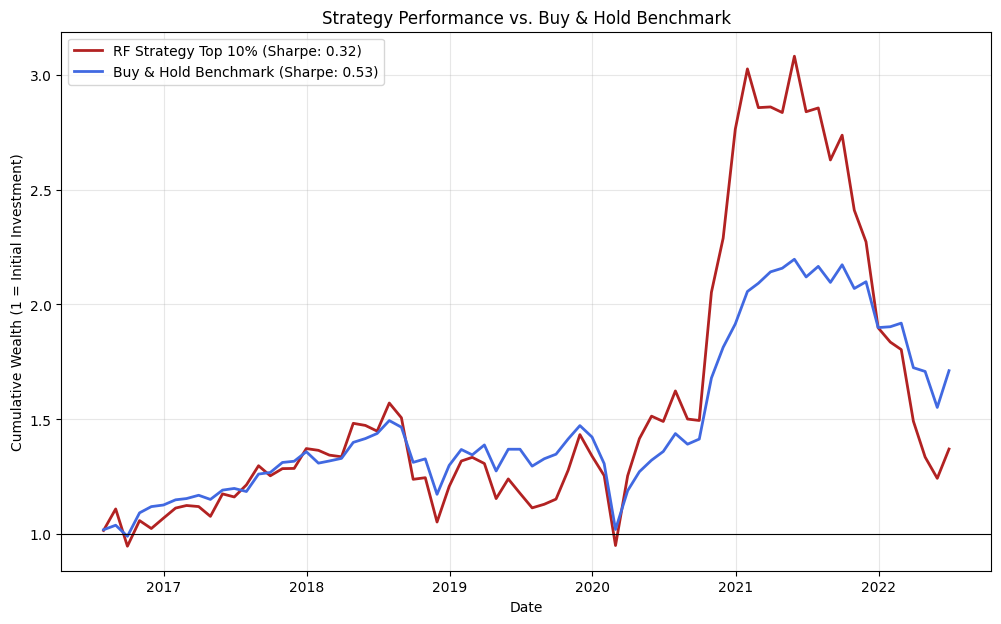

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取预测结果
print("正在加载测试集预测结果...")
df_test = pd.read_csv('rf_test_predictions_classifier.csv')
df_test['public_date'] = pd.to_datetime(df_test['public_date'])

# 2. 计算策略收益 (Long Top 10%)
def get_decile(x):
    return pd.qcut(x, 10, labels=False, duplicates='drop') + 1

df_test['Decile'] = df_test.groupby('public_date')['rf_predict_score'].transform(get_decile)
long_portfolio = df_test[df_test['Decile'] == 10].copy()

# 策略每月收益
port_ret = long_portfolio.groupby('public_date')['next_month_ret'].mean().reset_index()
port_ret.rename(columns={'next_month_ret': 'Strategy_Return'}, inplace=True)

# 3. 【新增】计算 Buy & Hold 基准收益 (全市场等权)
# 逻辑：不做任何预测筛选，直接把当月所有股票的收益率取平均，模拟“买下整个市场并持有”
benchmark_ret = df_test.groupby('public_date')['next_month_ret'].mean().reset_index()
benchmark_ret.rename(columns={'next_month_ret': 'Benchmark_Return'}, inplace=True)

# 将基准收益合并到策略结果表中
port_ret = pd.merge(port_ret, benchmark_ret, on='public_date')

# 4. 扣除交易成本 (策略需要换手扣 10bps，基准假设一直持有不扣费)
cost_bps = 10 
monthly_cost = (cost_bps * 2) / 10000 
port_ret['Strategy_Net_10bps'] = port_ret['Strategy_Return'] - monthly_cost

# 5. 计算累计净值
port_ret['Cum_Strategy_Net'] = (1 + port_ret['Strategy_Net_10bps']).cumprod()
port_ret['Cum_Benchmark'] = (1 + port_ret['Benchmark_Return']).cumprod()

# 6. 计算核心指标对比
def calc_metrics(ret_series):
    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol
    return ann_ret, ann_vol, sharpe

strat_ret, strat_vol, strat_sharpe = calc_metrics(port_ret['Strategy_Net_10bps'])
bench_ret, bench_vol, bench_sharpe = calc_metrics(port_ret['Benchmark_Return'])

print(f"\n=== 策略 vs Buy & Hold (基准) 核心指标对比 ===")
print(f"[你的 RF 策略] 年化收益: {strat_ret:.2f}% | 波动率: {strat_vol:.2f}% | 夏普: {strat_sharpe:.2f}")
print(f"[全市场基准]   年化收益: {bench_ret:.2f}% | 波动率: {bench_vol:.2f}% | 夏普: {bench_sharpe:.2f}")

# 7. 画出双线对比图
plt.figure(figsize=(12, 7))
# 你的策略曲线 (红色)
plt.plot(port_ret['public_date'], port_ret['Cum_Strategy_Net'], label=f'RF Strategy Top 10% (Sharpe: {strat_sharpe:.2f})', color='firebrick', linewidth=2)
# Buy & Hold 基准曲线 (蓝色)
plt.plot(port_ret['public_date'], port_ret['Cum_Benchmark'], label=f'Buy & Hold Benchmark (Sharpe: {bench_sharpe:.2f})', color='royalblue', linewidth=2, linestyle='-')

plt.axhline(1, color='black', linewidth=0.8)
plt.title('Strategy Performance vs. Buy & Hold Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (1 = Initial Investment)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

# 阶段 5：多空对冲 - Long Top 10% + Short Bottom 10%
在分类模型基础上构建零成本 Long-Short 对冲组合。

正在加载测试集分类预测结果...

=== 多头 vs 多空 vs 基准 核心指标对比 ===
[纯多头 (Long-Only)]   年化收益: 11.40% | 波动率: 35.81% | 夏普: 0.32
[多空对冲 (Long-Short)] 年化收益: -4.90% | 波动率: 28.81% | 夏普: -0.17
[全市场基准 (Benchmark)]年化收益: 11.32% | 波动率: 21.52% | 夏普: 0.53


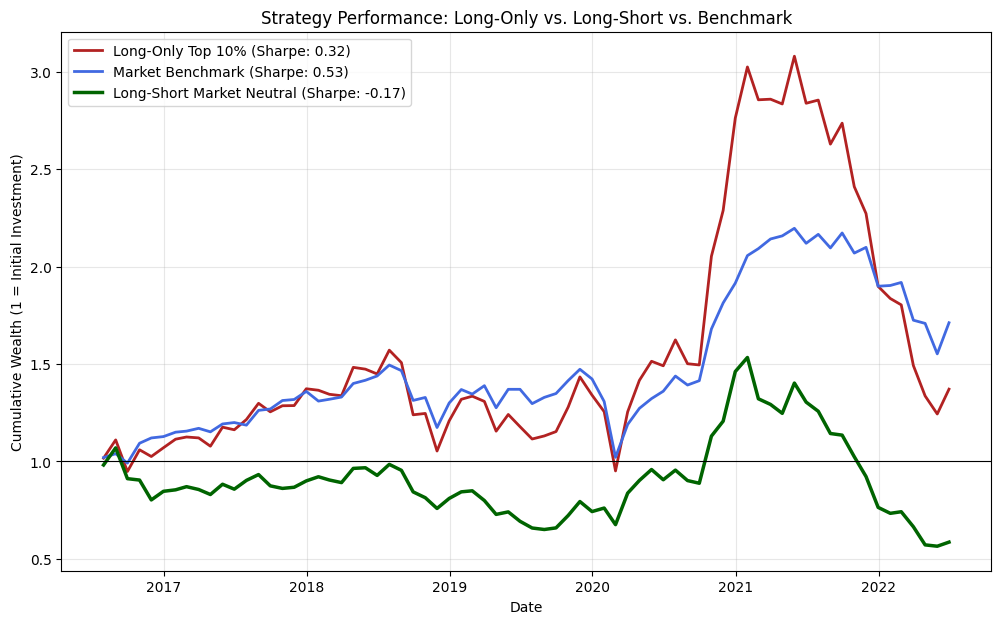

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("正在加载测试集分类预测结果...")
df_test = pd.read_csv('rf_test_predictions_classifier.csv')
df_test['public_date'] = pd.to_datetime(df_test['public_date'])

# 1. 按照预测概率(好股概率)分成 10 组
def get_decile(x):
    return pd.qcut(x, 10, labels=False, duplicates='drop') + 1

df_test['Decile'] = df_test.groupby('public_date')['rf_predict_score'].transform(get_decile)

# 2. 计算各组收益
# 做多：前 10% 尖子生
ret_long = df_test[df_test['Decile'] == 10].groupby('public_date')['next_month_ret'].mean().reset_index()
ret_long.rename(columns={'next_month_ret': 'Long_Return'}, inplace=True)

# 做空：后 10% 差生 (注意：做空跌了才赚钱)
ret_short = df_test[df_test['Decile'] == 1].groupby('public_date')['next_month_ret'].mean().reset_index()
ret_short.rename(columns={'next_month_ret': 'Short_Return'}, inplace=True)

# 基准：全市场等权
ret_bench = df_test.groupby('public_date')['next_month_ret'].mean().reset_index()
ret_bench.rename(columns={'next_month_ret': 'Bench_Return'}, inplace=True)

# 合并收益表
port_ret = pd.merge(ret_long, ret_short, on='public_date')
port_ret = pd.merge(port_ret, ret_bench, on='public_date')

# 3. 核心计算：构建 Long-Short 多空对冲组合收益
# 逻辑：做多 $1 的好股，做空 $1 的差股。这是零成本对冲组合。
port_ret['LS_Return'] = port_ret['Long_Return'] - port_ret['Short_Return']

# 4. 扣除交易成本 (做多做空双边都需要换手，所以摩擦成本更高，假设双边各扣 10bps)
cost_bps = 10 
monthly_cost_long = (cost_bps * 2) / 10000 
monthly_cost_ls = (cost_bps * 4) / 10000 # 多空双边交易，成本翻倍

port_ret['Net_Long'] = port_ret['Long_Return'] - monthly_cost_long
port_ret['Net_LS'] = port_ret['LS_Return'] - monthly_cost_ls

# 5. 计算累计净值 (Wealth Index)
port_ret['Cum_Long'] = (1 + port_ret['Net_Long']).cumprod()
# 对于零成本的对冲组合，标准的累计收益计算通常是加在初始本金 1 上
port_ret['Cum_LS'] = (1 + port_ret['Net_LS']).cumprod() 
port_ret['Cum_Bench'] = (1 + port_ret['Bench_Return']).cumprod()

# 6. 计算核心指标对比
def calc_metrics(ret_series):
    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
    return ann_ret, ann_vol, sharpe

long_ret, long_vol, long_sharpe = calc_metrics(port_ret['Net_Long'])
ls_ret, ls_vol, ls_sharpe = calc_metrics(port_ret['Net_LS'])
bench_ret, bench_vol, bench_sharpe = calc_metrics(port_ret['Bench_Return'])

print(f"\n=== 多头 vs 多空 vs 基准 核心指标对比 ===")
print(f"[纯多头 (Long-Only)]   年化收益: {long_ret:.2f}% | 波动率: {long_vol:.2f}% | 夏普: {long_sharpe:.2f}")
print(f"[多空对冲 (Long-Short)] 年化收益: {ls_ret:.2f}% | 波动率: {ls_vol:.2f}% | 夏普: {ls_sharpe:.2f}")
print(f"[全市场基准 (Benchmark)]年化收益: {bench_ret:.2f}% | 波动率: {bench_vol:.2f}% | 夏普: {bench_sharpe:.2f}")

# 7. 画出华丽的三线对比图
plt.figure(figsize=(12, 7))
plt.plot(port_ret['public_date'], port_ret['Cum_Long'], label=f'Long-Only Top 10% (Sharpe: {long_sharpe:.2f})', color='firebrick', linewidth=2)
plt.plot(port_ret['public_date'], port_ret['Cum_Bench'], label=f'Market Benchmark (Sharpe: {bench_sharpe:.2f})', color='royalblue', linewidth=2, linestyle='-')
plt.plot(port_ret['public_date'], port_ret['Cum_LS'], label=f'Long-Short Market Neutral (Sharpe: {ls_sharpe:.2f})', color='darkgreen', linewidth=2.5)

plt.axhline(1, color='black', linewidth=0.8)
plt.title('Strategy Performance: Long-Only vs. Long-Short vs. Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (1 = Initial Investment)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

# 阶段 6：利润驱动 - Alpha-Weighted 训练
用超额收益绝对值作为样本权重，让模型重点关注高Alpha利润的股票。

(Profit-Weighted Gini Impurity. R 
i,t+1
​	
  就是股票 i 在下个月的真实绝对收益率 (next_month_ret)。

我们取绝对值，是因为不管它是暴涨 50%（标签 1）还是暴跌 50%（标签 -1），对多空对冲组合来说，它们提供的 Alpha 利润空间都是巨大的，模型都必须重点关注。 
防止Fat Tails
Active Return / Market-Adjusted Weighting

In [23]:
# ==========================================
# 终极加分项：Alpha-Weighted 利润最大化多窗口 Grid Search
# ==========================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

print(">>> 启动基于利润最大化的 Grid Search (Alpha-Weighted 版)...\n")

# 1. 加载数据与特征
df = pd.read_csv('final_master_panel_large_caps.csv')
df['public_date'] = pd.to_datetime(df['public_date'])

features = [
    'mom_12_1', 'reversal_1m', 'vol_12m', 'ps', 'turnover',
    'log_mcap', 'pcf', 'bm', 'ptb', 'GProf',
    'aftret_invcapx', 'roa', 'pay_turn', 'evm', 'pe_op_basic',
    'CAPEI', 'pe_op_dil', 'roce', 'gpm', 'cash_ratio',
]

# 2. 打截面标签 (1, 0, -1)
def assign_labels(x):
    q30 = x.quantile(0.3)
    q70 = x.quantile(0.7)
    return np.select([x >= q70, x <= q30], [1, -1], default=0)

df['target_class'] = df.groupby('public_date')['next_month_ret'].transform(assign_labels)
target = 'target_class'

# 3. 准备时间切片
df_idx = df.set_index('public_date').sort_index()
months = sorted(df_idx.index.to_period('M').unique())

# 定义想要探索的参数网格
depth_options = [4, 5, 6, 8, 10, None]  # None 代表不限制深度
leaf_options = [10, 30, 50, 100, 150, 200, 400]            # 每片叶子至少包含50、100或150只股票

best_params = None
best_valid_profit = -float('inf') # 这次我们寻找的是“最大利润”，所以初始值设为负无穷

# 依然抽取 3 个代表性的历史时期进行验证 (跨越牛熊)
anchor_points = [-84, -48, -12] 

for d in depth_options:
    for l in leaf_options:
        print(f"正在测试参数组合: max_depth={d}, min_samples_leaf={l}...")
        
        profits = [] # 记录这组参数在各个验证集上的【Top 10% 绝对收益】
        
        for anchor in anchor_points:
            if abs(anchor) + 36 > len(months):
                continue
                
            t_start, t_end = str(months[anchor - 36]), str(months[anchor - 1])
            v_start = str(months[anchor])
            v_end_idx = anchor + 11 if anchor + 11 < 0 else -1
            v_end = str(months[v_end_idx])
            
            train_df = df_idx.loc[t_start : t_end].copy()
            valid_df = df_idx.loc[v_start : v_end].copy()
            
            X_train, y_train = train_df[features], train_df[target]
            X_valid = valid_df[features]
            
            # 【核心：Alpha 超额收益加权】
            monthly_mean = train_df.groupby('public_date')['next_month_ret'].transform('mean')
            active_return = train_df['next_month_ret'] - monthly_mean
            cap_threshold = np.abs(active_return).quantile(0.90)
            smoothed_weights = np.clip(np.abs(active_return), a_min=0, a_max=cap_threshold)
            profit_weights = smoothed_weights + 0.05
            
            # 训练模型
            rfc = RandomForestClassifier(
                n_estimators=100, # 调参时树少一点，跑得快
                max_depth=d, 
                min_samples_leaf=l, 
                max_features='sqrt',
                random_state=42, 
                n_jobs=-1
            )
            rfc.fit(X_train, y_train, sample_weight=profit_weights)
            
            # 【核心：利润评估法】预测验证集概率
            class_1_idx = list(rfc.classes_).index(1)
            valid_df['rf_predict_score'] = rfc.predict_proba(X_valid)[:, class_1_idx]
            
            # 在验证集里挑出 Top 10%，看看真实收益是多少
            def get_decile(x):
                return pd.qcut(x, 10, labels=False, duplicates='drop') + 1
            valid_df['Decile'] = valid_df.groupby('public_date')['rf_predict_score'].transform(get_decile)
            
            top_10_profit = valid_df[valid_df['Decile'] == 10]['next_month_ret'].mean()
            profits.append(top_10_profit)
            
        # 计算跨期平均利润
        avg_profit = np.mean(profits)
        print(f"  └─ 跨期验证集 Top 10% 平均月收益: {avg_profit * 100:.3f}%")
        
        # 选出最赚钱的参数！
        if avg_profit > best_valid_profit:
            best_valid_profit = avg_profit
            best_params = {'max_depth': d, 'min_samples_leaf': l}

print("\n==========================================")
print(f"🏆 调优完成！能够榨取最大超额收益的黄金参数是: {best_params}")
print("==========================================")

>>> 启动基于利润最大化的 Grid Search (Alpha-Weighted 版)...

正在测试参数组合: max_depth=4, min_samples_leaf=10...
  └─ 跨期验证集 Top 10% 平均月收益: -0.072%
正在测试参数组合: max_depth=4, min_samples_leaf=30...
  └─ 跨期验证集 Top 10% 平均月收益: -0.125%
正在测试参数组合: max_depth=4, min_samples_leaf=50...
  └─ 跨期验证集 Top 10% 平均月收益: -0.166%
正在测试参数组合: max_depth=4, min_samples_leaf=100...
  └─ 跨期验证集 Top 10% 平均月收益: -0.205%
正在测试参数组合: max_depth=4, min_samples_leaf=150...
  └─ 跨期验证集 Top 10% 平均月收益: -0.223%
正在测试参数组合: max_depth=4, min_samples_leaf=200...
  └─ 跨期验证集 Top 10% 平均月收益: -0.202%
正在测试参数组合: max_depth=4, min_samples_leaf=400...
  └─ 跨期验证集 Top 10% 平均月收益: -0.223%
正在测试参数组合: max_depth=5, min_samples_leaf=10...
  └─ 跨期验证集 Top 10% 平均月收益: -0.221%
正在测试参数组合: max_depth=5, min_samples_leaf=30...
  └─ 跨期验证集 Top 10% 平均月收益: -0.168%
正在测试参数组合: max_depth=5, min_samples_leaf=50...
  └─ 跨期验证集 Top 10% 平均月收益: -0.224%
正在测试参数组合: max_depth=5, min_samples_leaf=100...
  └─ 跨期验证集 Top 10% 平均月收益: -0.183%
正在测试参数组合: max_depth=5, min_samples_leaf=150...
  └─ 跨期验证集 Top 10%

In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

print(">>> 1. 正在加载纯净大盘股数据...")
df = pd.read_csv('final_master_panel_large_caps.csv')
df['public_date'] = pd.to_datetime(df['public_date'])

features = [
    'mom_12_1', 'reversal_1m', 'vol_12m', 'ps', 'turnover',
    'log_mcap', 'pcf', 'bm', 'ptb', 'GProf',
    'aftret_invcapx', 'roa', 'pay_turn', 'evm', 'pe_op_basic',
    'CAPEI', 'pe_op_dil', 'roce', 'gpm', 'cash_ratio',
]

print(">>> 2. 正在执行截面标签转换 (前30%=1, 后30%=-1, 中间=0)...")
def assign_labels(x):
    q30 = x.quantile(0.3)
    q70 = x.quantile(0.7)
    return np.select([x >= q70, x <= q30], [1, -1], default=0)

df['target_class'] = df.groupby('public_date')['next_month_ret'].transform(assign_labels)
target = 'target_class'

# ==========================================
# 3. 滚动训练准备
# ==========================================
df_idx = df.set_index('public_date').sort_index()
months = sorted(df_idx.index.to_period('M').unique())

all_test_predictions = []
train_len, gap_len, valid_len, test_len, step = 36, 3, 12, 12, 12

print(">>> 3. 开始执行 Alpha-Weighted (超额利润加权) 分类森林训练...\n")
start_i = 0
while True:
    train_end_i = start_i + train_len
    valid_start_i = train_end_i + gap_len
    valid_end_i = valid_start_i + valid_len
    test_start_i = valid_end_i + gap_len
    test_end_i = test_start_i + test_len
    
    if test_end_i > len(months): break
        
    t_start, t_end = str(months[start_i]), str(months[train_end_i - 1])
    v_start, v_end = str(months[valid_start_i]), str(months[valid_end_i - 1])
    te_start, te_end = str(months[test_start_i]), str(months[test_end_i - 1])
    
    train_df = df_idx.loc[t_start:t_end]
    valid_df = df_idx.loc[v_start:v_end]
    test_df  = df_idx.loc[te_start:te_end]
    
    X_train, y_train = train_df[features], train_df[target]
    X_test,  y_test  = test_df[features],  test_df[target]
    
    # 【终极黑科技：Alpha 超额收益加权】
    monthly_mean = train_df.groupby('public_date')['next_month_ret'].transform('mean')
    active_return = train_df['next_month_ret'] - monthly_mean
    cap_threshold = np.abs(active_return).quantile(0.90)
    smoothed_weights = np.clip(np.abs(active_return), a_min=0, a_max=cap_threshold)
    profit_weights = smoothed_weights + 0.05
    
    # 🌟 终极装甲：填入机器算出的黄金参数！
    rfc = RandomForestClassifier(
        n_estimators=300, 
        max_depth=10,                # 机器认证的最佳深度
        min_samples_leaf=50,        # 机器认证的防妖股底线
        max_features='sqrt',
        random_state=42, 
        n_jobs=-1
    )
    
    rfc.fit(X_train, y_train, sample_weight=profit_weights)
    class_1_idx = list(rfc.classes_).index(1)
    
    test_df_copy = test_df.copy()
    test_df_copy['rf_predict_score'] = rfc.predict_proba(X_test)[:, class_1_idx]
    all_test_predictions.append(test_df_copy)
    
    start_i += step

print(">>> 超额利润加权版训练完毕！")

# 存盘
df_final_test = pd.concat(all_test_predictions).reset_index()
df_final_test.to_csv('rf_test_predictions_alpha_weighted.csv', index=False)
print(">>> 打分已保存至 'rf_test_predictions_alpha_weighted.csv'！")

>>> 1. 正在加载纯净大盘股数据...
>>> 2. 正在执行截面标签转换 (前30%=1, 后30%=-1, 中间=0)...
>>> 3. 开始执行 Alpha-Weighted (超额利润加权) 分类森林训练...

>>> 超额利润加权版训练完毕！
>>> 打分已保存至 'rf_test_predictions_alpha_weighted.csv'！


正在加载测试集利润加权预测结果...

=== 🏆 利润驱动版 RF 策略 vs 大盘基准 ===
[利润加权 RF (Long-Only)] 年化收益: 11.39% | 波动率: 29.76% | 夏普: 0.38
[全市场基准 (Benchmark)]   年化收益: 11.32% | 波动率: 21.52% | 夏普: 0.53


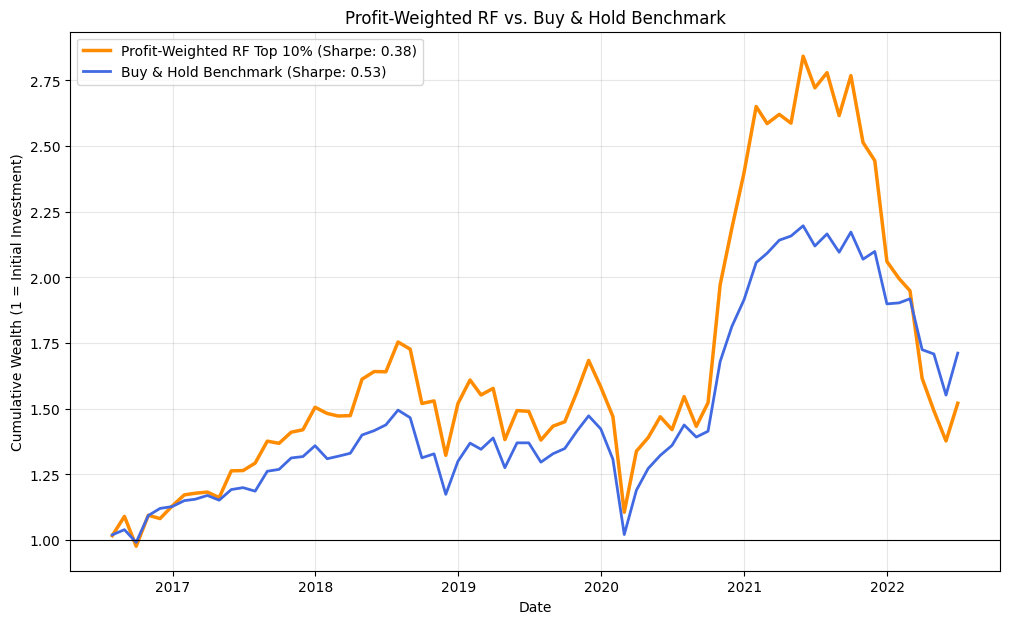

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("正在加载测试集利润加权预测结果...")
df_test = pd.read_csv('rf_test_predictions_alpha_weighted.csv')
df_test['public_date'] = pd.to_datetime(df_test['public_date'])

# 1. 按月分为 10 组
def get_decile(x):
    return pd.qcut(x, 10, labels=False, duplicates='drop') + 1

df_test['Decile'] = df_test.groupby('public_date')['rf_predict_score'].transform(get_decile)

# 2. 我们依然采用最稳健的纯多头 (Long Top 10%)
long_portfolio = df_test[df_test['Decile'] == 10].copy()

port_ret = long_portfolio.groupby('public_date')['next_month_ret'].mean().reset_index()
port_ret.rename(columns={'next_month_ret': 'Strategy_Return'}, inplace=True)

benchmark_ret = df_test.groupby('public_date')['next_month_ret'].mean().reset_index()
benchmark_ret.rename(columns={'next_month_ret': 'Benchmark_Return'}, inplace=True)

port_ret = pd.merge(port_ret, benchmark_ret, on='public_date')

# 扣除单边 10bps 交易成本
cost_bps = 10 
monthly_cost = (cost_bps * 2) / 10000 
port_ret['Strategy_Net_10bps'] = port_ret['Strategy_Return'] - monthly_cost

port_ret['Cum_Strategy_Net'] = (1 + port_ret['Strategy_Net_10bps']).cumprod()
port_ret['Cum_Benchmark'] = (1 + port_ret['Benchmark_Return']).cumprod()

def calc_metrics(ret_series):
    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol
    return ann_ret, ann_vol, sharpe

strat_ret, strat_vol, strat_sharpe = calc_metrics(port_ret['Strategy_Net_10bps'])
bench_ret, bench_vol, bench_sharpe = calc_metrics(port_ret['Benchmark_Return'])

print(f"\n=== 🏆 利润驱动版 RF 策略 vs 大盘基准 ===")
print(f"[利润加权 RF (Long-Only)] 年化收益: {strat_ret:.2f}% | 波动率: {strat_vol:.2f}% | 夏普: {strat_sharpe:.2f}")
print(f"[全市场基准 (Benchmark)]   年化收益: {bench_ret:.2f}% | 波动率: {bench_vol:.2f}% | 夏普: {bench_sharpe:.2f}")

# 画图
plt.figure(figsize=(12, 7))
plt.plot(port_ret['public_date'], port_ret['Cum_Strategy_Net'], label=f'Profit-Weighted RF Top 10% (Sharpe: {strat_sharpe:.2f})', color='darkorange', linewidth=2.5)
plt.plot(port_ret['public_date'], port_ret['Cum_Benchmark'], label=f'Buy & Hold Benchmark (Sharpe: {bench_sharpe:.2f})', color='royalblue', linewidth=2, linestyle='-')

plt.axhline(1, color='black', linewidth=0.8)
plt.title('Profit-Weighted RF vs. Buy & Hold Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (1 = Initial Investment)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

# 阶段 8：Sharpe 驱动调参
以验证集夏普比率（而非MSE或利润）作为优化目标的 Grid Search。

In [30]:
# ==========================================
# 终极加分项：Alpha-Weighted 夏普最大化多窗口 Grid Search
# ==========================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

print(">>> 启动基于【夏普比率最大化】的 Grid Search (Alpha-Weighted 版)...\n")

# 1. 加载数据与特征
df = pd.read_csv('final_master_panel_large_caps.csv')
df['public_date'] = pd.to_datetime(df['public_date'])

features = [
    'mom_12_1', 'reversal_1m', 'vol_12m', 'ps', 'turnover',
    'log_mcap', 'pcf', 'bm', 'ptb', 'GProf',
    'aftret_invcapx', 'roa', 'pay_turn', 'evm', 'pe_op_basic',
    'CAPEI', 'pe_op_dil', 'roce', 'gpm', 'cash_ratio',
]

# 2. 打截面标签 (1, 0, -1)
def assign_labels(x):
    q30 = x.quantile(0.3)
    q70 = x.quantile(0.7)
    return np.select([x >= q70, x <= q30], [1, -1], default=0)

df['target_class'] = df.groupby('public_date')['next_month_ret'].transform(assign_labels)
target = 'target_class'

# 3. 准备时间切片
df_idx = df.set_index('public_date').sort_index()
months = sorted(df_idx.index.to_period('M').unique())

# 参数网格
depth_options = [4, 5, 6, 8, 10, None]  
leaf_options = [10, 30, 50, 100, 150, 200, 400]            

best_params = None
best_valid_sharpe = -float('inf') # 🌟 这次寻找最大夏普

anchor_points = [-84, -48, -12] 

for d in depth_options:
    for l in leaf_options:
        print(f"正在测试参数组合: max_depth={d}, min_samples_leaf={l}...")
        
        sharpes = [] # 🌟 记录这组参数在各个验证集上的【Top 10% 夏普比率】
        
        for anchor in anchor_points:
            if abs(anchor) + 36 > len(months):
                continue
                
            t_start, t_end = str(months[anchor - 36]), str(months[anchor - 1])
            v_start = str(months[anchor])
            v_end_idx = anchor + 11 if anchor + 11 < 0 else -1
            v_end = str(months[v_end_idx])
            
            train_df = df_idx.loc[t_start : t_end].copy()
            valid_df = df_idx.loc[v_start : v_end].copy()
            
            X_train, y_train = train_df[features], train_df[target]
            X_valid = valid_df[features]
            
            # Alpha 超额收益加权
            monthly_mean = train_df.groupby('public_date')['next_month_ret'].transform('mean')
            active_return = train_df['next_month_ret'] - monthly_mean
            cap_threshold = np.abs(active_return).quantile(0.90)
            smoothed_weights = np.clip(np.abs(active_return), a_min=0, a_max=cap_threshold)
            profit_weights = smoothed_weights + 0.05
            
            rfc = RandomForestClassifier(
                n_estimators=100, 
                max_depth=d, 
                min_samples_leaf=l, 
                max_features='sqrt',
                random_state=42, 
                n_jobs=-1
            )
            rfc.fit(X_train, y_train, sample_weight=profit_weights)
            
            class_1_idx = list(rfc.classes_).index(1)
            valid_df['rf_predict_score'] = rfc.predict_proba(X_valid)[:, class_1_idx]
            
            def get_decile(x):
                return pd.qcut(x, 10, labels=False, duplicates='drop') + 1
            valid_df['Decile'] = valid_df.groupby('public_date')['rf_predict_score'].transform(get_decile)
            
            # 🌟 计算验证集的真实夏普比率
            top_10_rets = valid_df[valid_df['Decile'] == 10].groupby('public_date')['next_month_ret'].mean()
            if top_10_rets.std() == 0:
                sharpe = 0
            else:
                sharpe = (top_10_rets.mean() / top_10_rets.std()) * np.sqrt(12)
                
            sharpes.append(sharpe)
            
        # 计算跨期平均夏普
        avg_sharpe = np.mean(sharpes)
        print(f"  └─ 跨期验证集 Top 10% 平均夏普比率: {avg_sharpe:.3f}")
        
        # 🌟 选出夏普最高的参数！
        if avg_sharpe > best_valid_sharpe:
            best_valid_sharpe = avg_sharpe
            best_params = {'max_depth': d, 'min_samples_leaf': l}

print("\n==========================================")
print(f"🏆 调优完成！能够榨取最大【夏普比率】的黄金参数是: {best_params}")
print("==========================================")

>>> 启动基于【夏普比率最大化】的 Grid Search (Alpha-Weighted 版)...

正在测试参数组合: max_depth=4, min_samples_leaf=10...
  └─ 跨期验证集 Top 10% 平均夏普比率: 0.038
正在测试参数组合: max_depth=4, min_samples_leaf=30...
  └─ 跨期验证集 Top 10% 平均夏普比率: 0.024
正在测试参数组合: max_depth=4, min_samples_leaf=50...
  └─ 跨期验证集 Top 10% 平均夏普比率: 0.003
正在测试参数组合: max_depth=4, min_samples_leaf=100...
  └─ 跨期验证集 Top 10% 平均夏普比率: -0.013
正在测试参数组合: max_depth=4, min_samples_leaf=150...
  └─ 跨期验证集 Top 10% 平均夏普比率: -0.021
正在测试参数组合: max_depth=4, min_samples_leaf=200...
  └─ 跨期验证集 Top 10% 平均夏普比率: -0.015
正在测试参数组合: max_depth=4, min_samples_leaf=400...
  └─ 跨期验证集 Top 10% 平均夏普比率: -0.025
正在测试参数组合: max_depth=5, min_samples_leaf=10...
  └─ 跨期验证集 Top 10% 平均夏普比率: -0.030
正在测试参数组合: max_depth=5, min_samples_leaf=30...
  └─ 跨期验证集 Top 10% 平均夏普比率: -0.021
正在测试参数组合: max_depth=5, min_samples_leaf=50...
  └─ 跨期验证集 Top 10% 平均夏普比率: -0.061
正在测试参数组合: max_depth=5, min_samples_leaf=100...
  └─ 跨期验证集 Top 10% 平均夏普比率: -0.019
正在测试参数组合: max_depth=5, min_samples_leaf=150...
  └─ 跨期验证集 Top 10

In [41]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import random
import os

# ==========================================
# 0. 绝对封印：锁死随机种子，确保 100% 可复现
# ==========================================
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42)

print(">>> 1. 加载数据与特征...")
df = pd.read_csv('final_master_panel_large_caps.csv')
df['public_date'] = pd.to_datetime(df['public_date'])

features = [
    'mom_12_1', 'reversal_1m', 'vol_12m', 'ps', 'turnover',
    'log_mcap', 'pcf', 'bm', 'ptb', 'GProf',
    'aftret_invcapx', 'roa', 'pay_turn', 'evm', 'pe_op_basic',
    'CAPEI', 'pe_op_dil', 'roce', 'gpm', 'cash_ratio',
]

def assign_labels(x):
    q30 = x.quantile(0.3)
    q70 = x.quantile(0.7)
    return np.select([x >= q70, x <= q30], [1, -1], default=0)

df['target_class'] = df.groupby('public_date')['next_month_ret'].transform(assign_labels)
target = 'target_class'

# ==========================================
# 2. 严谨的 Walk-Forward 滚动测试 (开奖专用)
# ==========================================
df_idx = df.set_index('public_date').sort_index()
months = sorted(df_idx.index.to_period('M').unique())

all_test_predictions = []

# 保持和之前一致的公平基准
train_len, gap_len, valid_len, test_len, step = 36, 3, 12, 12, 12

print(f">>> 3. 启动带 Gap 的滚动测试 (应用 Sharpe 最优参数)...\n")

start_i = 0
window_count = 1

while True:
    train_end_i = start_i + train_len
    valid_start_i = train_end_i + gap_len
    valid_end_i = valid_start_i + valid_len
    test_start_i = valid_end_i + gap_len
    test_end_i = test_start_i + test_len
    
    if test_end_i > len(months): break
        
    t_start, t_end = str(months[start_i]), str(months[train_end_i - 1])
    te_start, te_end = str(months[test_start_i]), str(months[test_end_i - 1])
    
    print(f"--- Rolling Window {window_count} ---")
    print(f"Train: {t_start} to {t_end} | Test (开奖): {te_start} to {te_end}")
    
    train_df = df_idx.loc[t_start:t_end].copy()
    test_df  = df_idx.loc[te_start:te_end].copy()
    
    X_train, y_train = train_df[features], train_df[target]
    X_test = test_df[features]
    
    # 【核心：Alpha 超额收益加权】
    monthly_mean = train_df.groupby('public_date')['next_month_ret'].transform('mean')
    active_return = train_df['next_month_ret'] - monthly_mean
    cap_threshold = np.abs(active_return).quantile(0.90)
    smoothed_weights = np.clip(np.abs(active_return), a_min=0, a_max=cap_threshold)
    profit_weights = smoothed_weights + 0.05
    
    # 🌟 祭出你在 Grid Search 里找到的“夏普怪兽”参数！
    rfc = RandomForestClassifier(
        n_estimators=100, 
        max_depth=None,         # 深度不设限 (极度容易过拟合)
        min_samples_leaf=10,    # 叶子极小 (对噪音极其敏感)
        max_features='sqrt',
        random_state=42, 
        n_jobs=-1
    )
    
    rfc.fit(X_train, y_train, sample_weight=profit_weights)
    
    class_1_idx = list(rfc.classes_).index(1)
    test_df['rf_predict_score'] = rfc.predict_proba(X_test)[:, class_1_idx]
    
    all_test_predictions.append(test_df)
    
    start_i += step
    window_count += 1

print("\n>>> 所有测试集开奖完毕！计算最终收益...")

# ==========================================
# 4. 终极回测开奖统计
# ==========================================
df_final_test = pd.concat(all_test_predictions).reset_index()

def get_decile(x):
    return pd.qcut(x, 10, labels=False, duplicates='drop') + 1

df_final_test['Decile'] = df_final_test.groupby('public_date')['rf_predict_score'].transform(get_decile)

rf_long_portfolio = df_final_test[df_final_test['Decile'] == 10]

rf_ret = rf_long_portfolio.groupby('public_date')['next_month_ret'].mean().reset_index()
bench_ret = df_final_test.groupby('public_date')['next_month_ret'].mean().reset_index()

rf_ann_ret = rf_ret['next_month_ret'].mean() * 12 * 100
rf_ann_vol = rf_ret['next_month_ret'].std() * np.sqrt(12) * 100
rf_sharpe = rf_ann_ret / rf_ann_vol

bench_ann_ret = bench_ret['next_month_ret'].mean() * 12 * 100
bench_ann_vol = bench_ret['next_month_ret'].std() * np.sqrt(12) * 100
bench_sharpe = bench_ann_ret / bench_ann_vol

print(f"\n🏆 === Sharpe 驱动版 RF 策略 vs 大盘基准 ===")
print(f"[夏普优化 RF (Long-Only)] 年化收益: {rf_ann_ret:.2f}% | 波动率: {rf_ann_vol:.2f}% | 夏普: {rf_sharpe:.2f}")
print(f"[全市场基准 (Benchmark)]   年化收益: {bench_ann_ret:.2f}% | 波动率: {bench_ann_vol:.2f}% | 夏普: {bench_sharpe:.2f}")

df_final_test.to_csv('rf_test_predictions_sharpe_driven.csv', index=False)

>>> 1. 加载数据与特征...
>>> 3. 启动带 Gap 的滚动测试 (应用 Sharpe 最优参数)...

--- Rolling Window 1 ---
Train: 2012-01 to 2014-12 | Test (开奖): 2016-07 to 2017-06
--- Rolling Window 2 ---
Train: 2013-01 to 2015-12 | Test (开奖): 2017-07 to 2018-06
--- Rolling Window 3 ---
Train: 2014-01 to 2016-12 | Test (开奖): 2018-07 to 2019-06
--- Rolling Window 4 ---
Train: 2015-01 to 2017-12 | Test (开奖): 2019-07 to 2020-06
--- Rolling Window 5 ---
Train: 2016-01 to 2018-12 | Test (开奖): 2020-07 to 2021-06
--- Rolling Window 6 ---
Train: 2017-01 to 2019-12 | Test (开奖): 2021-07 to 2022-06

>>> 所有测试集开奖完毕！计算最终收益...

🏆 === Sharpe 驱动版 RF 策略 vs 大盘基准 ===
[夏普优化 RF (Long-Only)] 年化收益: 11.82% | 波动率: 29.31% | 夏普: 0.40
[全市场基准 (Benchmark)]   年化收益: 11.32% | 波动率: 21.52% | 夏普: 0.53


正在加载 Sharpe 驱动版预测结果...


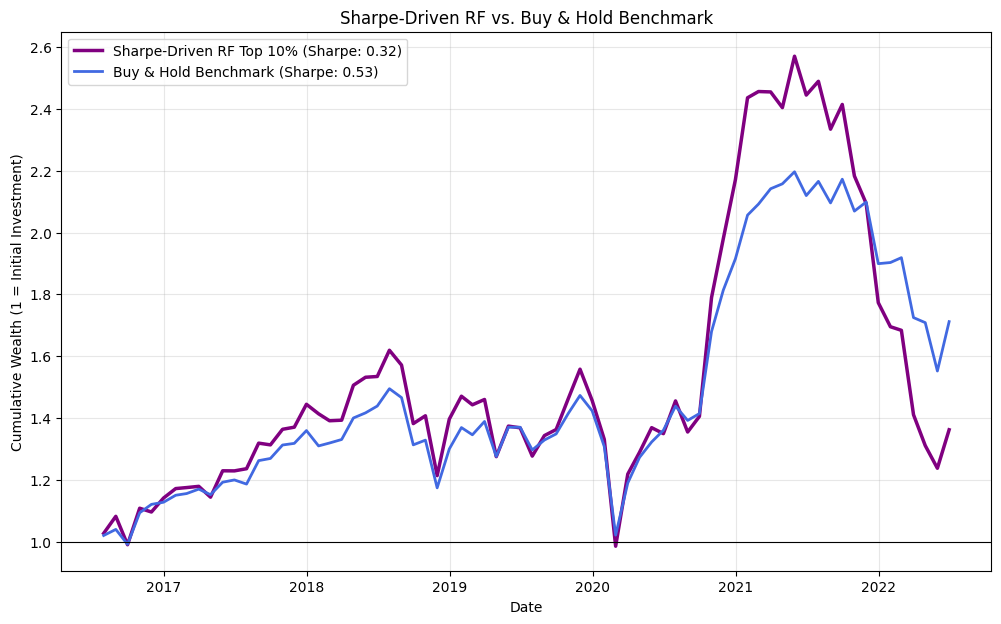

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("正在加载 Sharpe 驱动版预测结果...")
df_test = pd.read_csv('rf_test_predictions_sharpe_driven.csv')
df_test['public_date'] = pd.to_datetime(df_test['public_date'])

def get_decile(x):
    return pd.qcut(x, 10, labels=False, duplicates='drop') + 1

df_test['Decile'] = df_test.groupby('public_date')['rf_predict_score'].transform(get_decile)
long_portfolio = df_test[df_test['Decile'] == 10].copy()

port_ret = long_portfolio.groupby('public_date')['next_month_ret'].mean().reset_index()
port_ret.rename(columns={'next_month_ret': 'Strategy_Return'}, inplace=True)

benchmark_ret = df_test.groupby('public_date')['next_month_ret'].mean().reset_index()
benchmark_ret.rename(columns={'next_month_ret': 'Benchmark_Return'}, inplace=True)

port_ret = pd.merge(port_ret, benchmark_ret, on='public_date')

cost_bps = 10
monthly_cost = (cost_bps * 2) / 10000
port_ret['Strategy_Net_10bps'] = port_ret['Strategy_Return'] - monthly_cost

port_ret['Cum_Strategy_Net'] = (1 + port_ret['Strategy_Net_10bps']).cumprod()
port_ret['Cum_Benchmark'] = (1 + port_ret['Benchmark_Return']).cumprod()

def calc_metrics(ret_series):
    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol
    return ann_ret, ann_vol, sharpe

strat_ret, strat_vol, strat_sharpe = calc_metrics(port_ret['Strategy_Net_10bps'])
bench_ret, bench_vol, bench_sharpe = calc_metrics(port_ret['Benchmark_Return'])

plt.figure(figsize=(12, 7))
plt.plot(port_ret['public_date'], port_ret['Cum_Strategy_Net'], label=f'Sharpe-Driven RF Top 10% (Sharpe: {strat_sharpe:.2f})', color='purple', linewidth=2.5)
plt.plot(port_ret['public_date'], port_ret['Cum_Benchmark'], label=f'Buy & Hold Benchmark (Sharpe: {bench_sharpe:.2f})', color='royalblue', linewidth=2, linestyle='-')

plt.axhline(1, color='black', linewidth=0.8)
plt.title('Sharpe-Driven RF vs. Buy & Hold Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (1 = Initial Investment)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

# 阶段 9：所有模型版本结果汇总

              所有模型版本 Performance 汇总对比


,Stage,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%),Win_Rate(%)
0,1. Regression (51 feat),7.41,29.93,0.25,-56.64,55.6
1,2. Regression (Top 20),8.69,29.77,0.29,-55.65,55.6
2,3. Regression + Grid Search,10.85,28.48,0.38,-46.81,59.7
3,4. Classification (1/0/-1),11.40,35.81,0.32,-59.62,50.0
4,6. Profit-Driven (Alpha-Weighted),11.39,29.76,0.38,-51.53,56.9
5,7. Sharpe-Driven,9.42,29.31,0.32,-51.86,56.9
6,Benchmark (等权),11.32,21.52,0.53,-31.69,70.8


/var/folders/0k/7z1g8vr51n7_n_22vk6x3zrw0000gn/T/ipykernel_45758/2980450888.py:104: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0k/7z1g8vr51n7_n_22vk6x3zrw0000gn/T/ipykernel_45758/2980450888.py:104: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/cleanml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/cleanml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


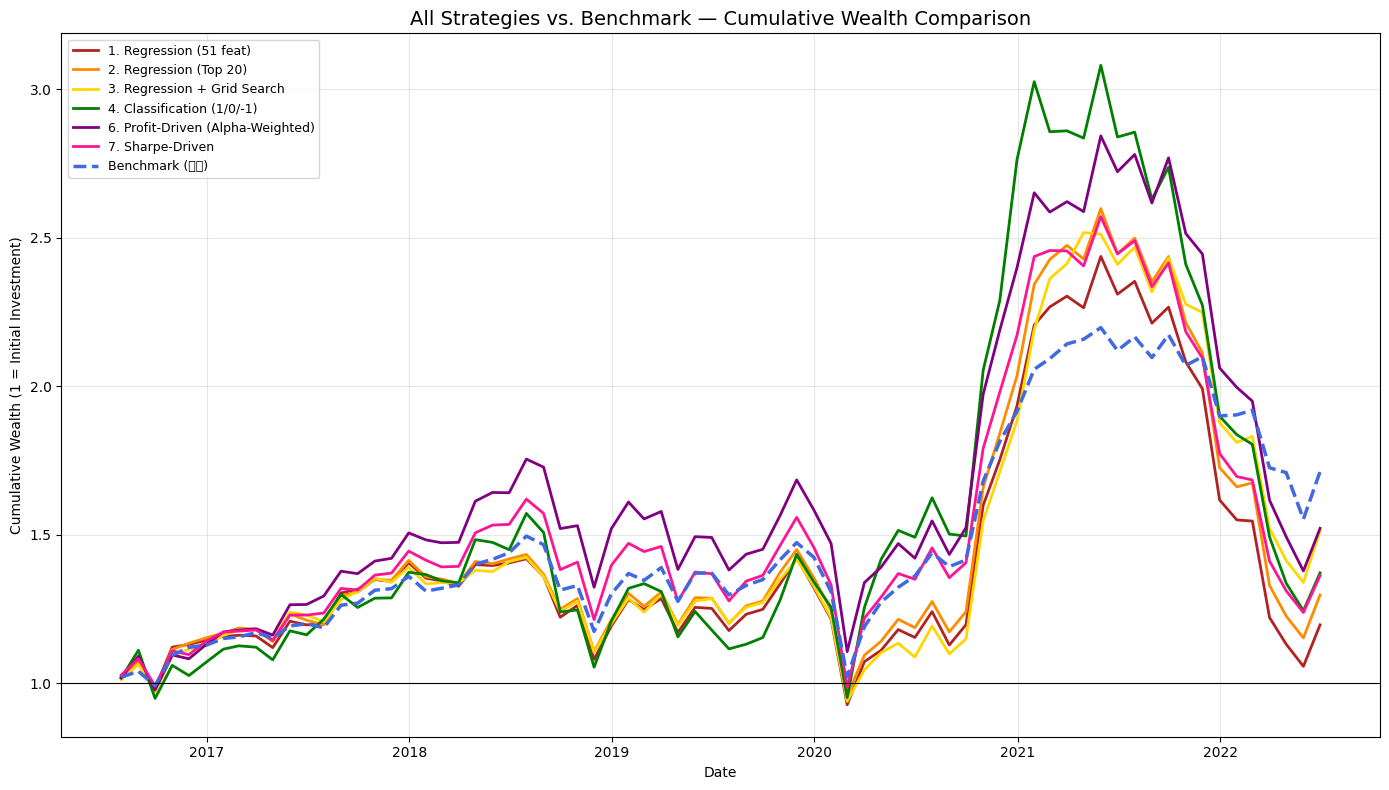

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 自动汇总：读取所有阶段的预测文件，统一计算指标
# ==========================================

# 定义所有阶段的预测文件和标签
stages = {
    'rf_test_predictions_large.csv':          '1. Regression (51 feat)',
    'rf_test_predictions_slim.csv':           '2. Regression (Top 20)',
    'rf_test_predictions_grid.csv':           '3. Regression + Grid Search',
    'rf_test_predictions_classifier.csv':     '4. Classification (1/0/-1)',
    'rf_test_predictions_alpha_weighted.csv': '6. Profit-Driven (Alpha-Weighted)',
    'rf_test_predictions_sharpe_driven.csv':  '7. Sharpe-Driven',
}

cost_bps = 10
monthly_cost = (cost_bps * 2) / 10000

all_results = []
all_curves = {}

for filename, label in stages.items():
    try:
        df_test = pd.read_csv(filename)
        df_test['public_date'] = pd.to_datetime(df_test['public_date'])
        
        def get_decile(x):
            return pd.qcut(x, 10, labels=False, duplicates='drop') + 1
        
        df_test['Decile'] = df_test.groupby('public_date')['rf_predict_score'].transform(get_decile)
        long_portfolio = df_test[df_test['Decile'] == 10]
        
        port_ret = long_portfolio.groupby('public_date')['next_month_ret'].mean().reset_index()
        port_ret['net_ret'] = port_ret['next_month_ret'] - monthly_cost
        port_ret['cum'] = (1 + port_ret['net_ret']).cumprod()
        
        ann_ret = port_ret['net_ret'].mean() * 12 * 100
        ann_vol = port_ret['net_ret'].std() * np.sqrt(12) * 100
        sharpe = ann_ret / ann_vol
        max_dd = (port_ret['cum'] / port_ret['cum'].cummax() - 1).min() * 100
        win_rate = (port_ret['net_ret'] > 0).mean() * 100
        
        all_results.append({
            'Stage': label,
            'Ann_Return(%)': round(ann_ret, 2),
            'Ann_Vol(%)': round(ann_vol, 2),
            'Sharpe': round(sharpe, 2),
            'Max_DD(%)': round(max_dd, 2),
            'Win_Rate(%)': round(win_rate, 1),
        })
        
        all_curves[label] = (port_ret['public_date'], port_ret['cum'])
        
    except FileNotFoundError:
        print(f"跳过 {filename}（文件不存在，可能该阶段未运行）")

# --- 加入基准 ---
df_bench = pd.read_csv('rf_test_predictions_classifier.csv')
df_bench['public_date'] = pd.to_datetime(df_bench['public_date'])
bench_ret = df_bench.groupby('public_date')['next_month_ret'].mean().reset_index()
bench_ret['cum'] = (1 + bench_ret['next_month_ret']).cumprod()
bench_ann_ret = bench_ret['next_month_ret'].mean() * 12 * 100
bench_ann_vol = bench_ret['next_month_ret'].std() * np.sqrt(12) * 100
bench_sharpe = bench_ann_ret / bench_ann_vol
bench_max_dd = (bench_ret['cum'] / bench_ret['cum'].cummax() - 1).min() * 100
bench_win_rate = (bench_ret['next_month_ret'] > 0).mean() * 100

all_results.append({
    'Stage': 'Benchmark (等权)',
    'Ann_Return(%)': round(bench_ann_ret, 2),
    'Ann_Vol(%)': round(bench_ann_vol, 2),
    'Sharpe': round(bench_sharpe, 2),
    'Max_DD(%)': round(bench_max_dd, 2),
    'Win_Rate(%)': round(bench_win_rate, 1),
})

# --- 展示汇总表 ---
results_df = pd.DataFrame(all_results)
print("=" * 85)
print("              所有模型版本 Performance 汇总对比")
print("=" * 85)
display(results_df)

# --- 画所有策略的累计净值对比图 ---
plt.figure(figsize=(14, 8))

colors = ['firebrick', 'darkorange', 'gold', 'green', 'purple', 'deeppink']
for (label, (dates, cum)), color in zip(all_curves.items(), colors):
    plt.plot(dates, cum, label=label, linewidth=2, color=color)

# 基准线
plt.plot(bench_ret['public_date'], bench_ret['cum'], 
         label='Benchmark (等权)', color='royalblue', linewidth=2.5, linestyle='--')

plt.axhline(1, color='black', linewidth=0.8)
plt.title('All Strategies vs. Benchmark — Cumulative Wealth Comparison', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (1 = Initial Investment)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

profit driven 

>>> 加载最优策略预测结果...
>>> 平均月度单边换手率: 31.71%

     交易摩擦成本敏感性分析 (Profit-Driven 策略)
     假设参数: 佣金=10bps | 滑点=20bps | 税率=25%
     实际平均月度换手率: 31.71%


,Scenario,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%)
0,A: Commission Only (10bps),11.39,29.76,0.38,-51.53
1,B: + Slippage (20bps),6.59,29.76,0.22,-53.95
2,C: + Real Turnover,11.44,29.75,0.38,-51.22
3,D: + Tax (25%),0.49,25.89,0.02,-52.15
4,Benchmark (等权),11.32,21.52,0.53,-31.69


/var/folders/0k/7z1g8vr51n7_n_22vk6x3zrw0000gn/T/ipykernel_45758/2783548135.py:169: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0k/7z1g8vr51n7_n_22vk6x3zrw0000gn/T/ipykernel_45758/2783548135.py:169: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/cleanml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/cleanml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


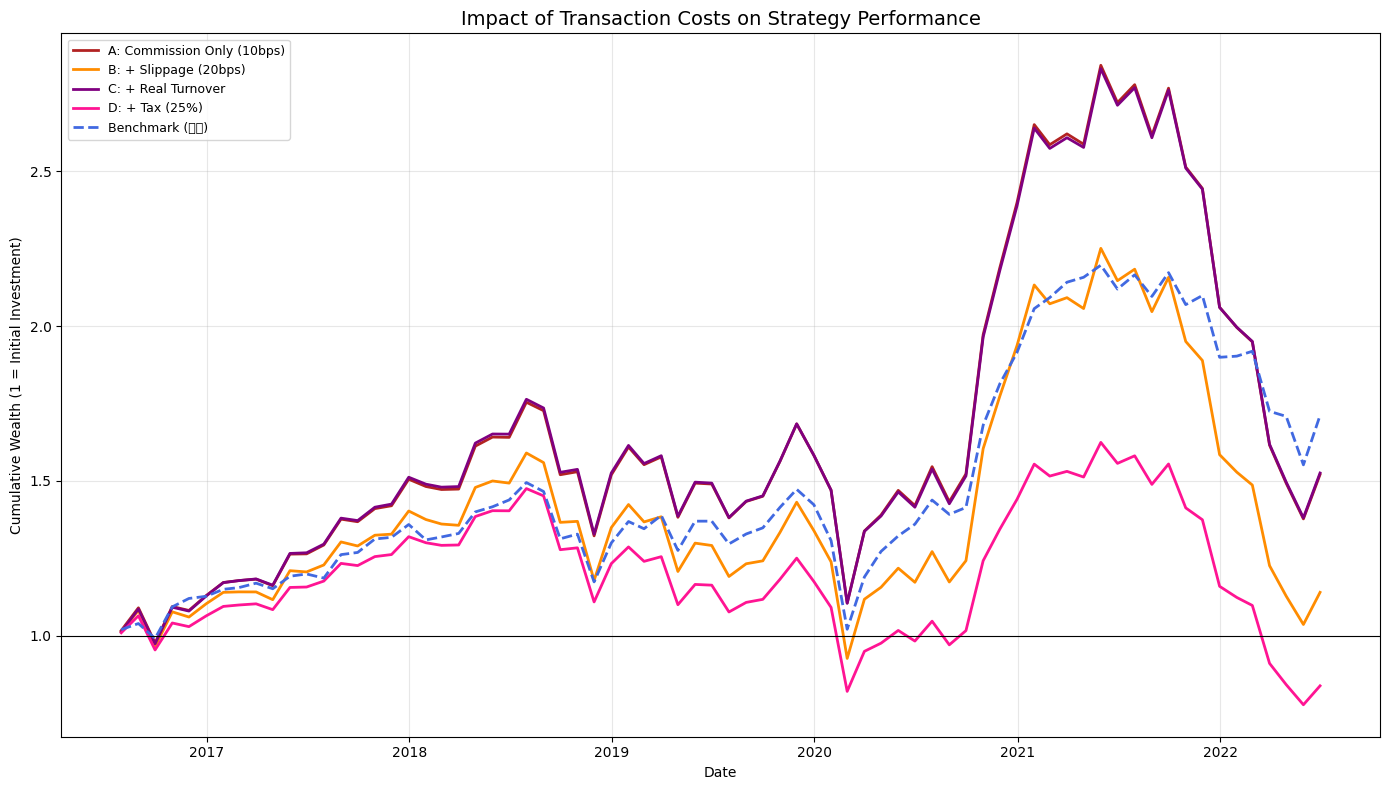

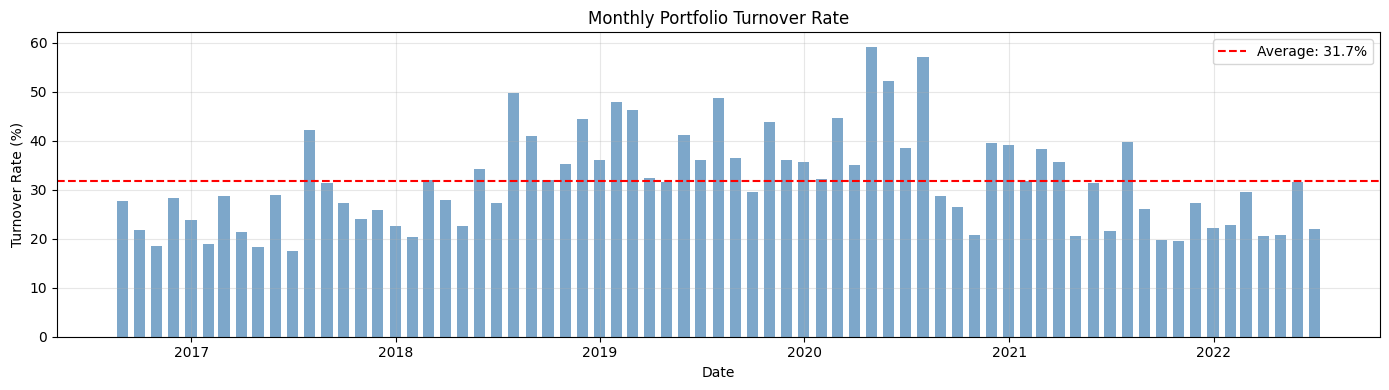

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 真实交易摩擦成本分析
# 在最优策略 (Profit-Driven) 基础上加入：
#   1. Slippage (滑点/市场冲击)
#   2. Rebalancing Turnover (换仓换手率)
#   3. Capital Gains Tax (资本利得税)
# ==========================================

print(">>> 加载最优策略预测结果...")
df_test = pd.read_csv('rf_test_predictions_alpha_weighted.csv')
df_test['public_date'] = pd.to_datetime(df_test['public_date'])

# ==========================================
# 1. 构建组合 & 计算换手率
# ==========================================
def get_decile(x):
    return pd.qcut(x, 10, labels=False, duplicates='drop') + 1

df_test['Decile'] = df_test.groupby('public_date')['rf_predict_score'].transform(get_decile)

# 获取每月 Top 10% 的股票列表
months_sorted = sorted(df_test['public_date'].unique())
monthly_holdings = {}
turnover_rates = []

for i, month in enumerate(months_sorted):
    current_top = set(df_test[(df_test['public_date'] == month) & (df_test['Decile'] == 10)]['permno'].values)
    monthly_holdings[month] = current_top
    
    if i > 0:
        prev_top = monthly_holdings[months_sorted[i-1]]
        # 换手率 = 新进入的股票数 / 组合总股票数
        new_stocks = current_top - prev_top
        turnover = len(new_stocks) / len(current_top) if len(current_top) > 0 else 0
        turnover_rates.append({'public_date': month, 'turnover_rate': turnover})

turnover_df = pd.DataFrame(turnover_rates)
avg_turnover = turnover_df['turnover_rate'].mean()
print(f">>> 平均月度单边换手率: {avg_turnover:.2%}")

# ==========================================
# 2. 计算每月策略收益
# ==========================================
long_portfolio = df_test[df_test['Decile'] == 10]
port_ret = long_portfolio.groupby('public_date')['next_month_ret'].mean().reset_index()
port_ret.rename(columns={'next_month_ret': 'Gross_Return'}, inplace=True)

# 合并换手率
port_ret = pd.merge(port_ret, turnover_df, on='public_date', how='left')
port_ret['turnover_rate'] = port_ret['turnover_rate'].fillna(1.0)  # 第一个月假设全仓建仓

# 基准收益
benchmark_ret = df_test.groupby('public_date')['next_month_ret'].mean().reset_index()
benchmark_ret.rename(columns={'next_month_ret': 'Benchmark_Return'}, inplace=True)
port_ret = pd.merge(port_ret, benchmark_ret, on='public_date')

# ==========================================
# 3. 定义各层成本参数
# ==========================================
# --- Scenario A: 原始版 (只有固定交易成本) ---
fixed_cost_bps = 10  # 单边 10bps
fixed_monthly = (fixed_cost_bps * 2) / 10000  # 双边

# --- Scenario B: + Slippage (市场冲击) ---
# 滑点通常取决于股票流动性和交易规模
# 小盘股滑点更高，大盘股更低
# 保守估计：单边 15-25bps 对机构投资者
slippage_bps = 20  # 单边 20bps

# --- Scenario C: + Rebalancing (基于真实换手率) ---
# 交易成本 = 换手率 × 单笔成本（佣金 + 滑点）
per_trade_cost_bps = 30  # 单笔成本：佣金10bps + 滑点20bps

# --- Scenario D: + Tax (短期资本利得税) ---
# 美国短期资本利得税（持有<1年）按普通收入税率
# 假设边际税率 25%（中等收入水平）
# 只对正收益部分征税
short_term_tax_rate = 0.25

# ==========================================
# 4. 计算各 Scenario 的净收益
# ==========================================

# Scenario A: 固定成本 (你原来的版本)
port_ret['Net_A'] = port_ret['Gross_Return'] - fixed_monthly

# Scenario B: 固定成本 + 滑点
total_fixed_slippage = (fixed_cost_bps + slippage_bps) * 2 / 10000
port_ret['Net_B'] = port_ret['Gross_Return'] - total_fixed_slippage

# Scenario C: 基于真实换手率的动态成本 + 滑点
# 每月成本 = 换手率 × 单笔成本(双边)
port_ret['dynamic_cost'] = port_ret['turnover_rate'] * (per_trade_cost_bps * 2) / 10000
port_ret['Net_C'] = port_ret['Gross_Return'] - port_ret['dynamic_cost']

# Scenario D: 动态成本 + 税
def apply_tax(row):
    net_before_tax = row['Net_C']
    if net_before_tax > 0:
        return net_before_tax * (1 - short_term_tax_rate)
    else:
        return net_before_tax  # 亏损不征税（简化处理）

port_ret['Net_D'] = port_ret.apply(apply_tax, axis=1)

# ==========================================
# 5. 计算累计净值 & 核心指标
# ==========================================
scenarios = {
    'A: Commission Only (10bps)': 'Net_A',
    'B: + Slippage (20bps)': 'Net_B',
    'C: + Real Turnover': 'Net_C',
    'D: + Tax (25%)': 'Net_D',
    'Benchmark (等权)': 'Benchmark_Return',
}

def calc_metrics(ret_series):
    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
    cum = (1 + ret_series).cumprod()
    max_dd = (cum / cum.cummax() - 1).min() * 100
    return ann_ret, ann_vol, sharpe, max_dd

print("\n" + "=" * 80)
print("     交易摩擦成本敏感性分析 (Profit-Driven 策略)")
print("=" * 80)
print(f"     假设参数: 佣金={fixed_cost_bps}bps | 滑点={slippage_bps}bps | 税率={short_term_tax_rate:.0%}")
print(f"     实际平均月度换手率: {avg_turnover:.2%}")
print("=" * 80)

results = []
for label, col in scenarios.items():
    ann_ret, ann_vol, sharpe, max_dd = calc_metrics(port_ret[col])
    results.append({
        'Scenario': label,
        'Ann_Return(%)': round(ann_ret, 2),
        'Ann_Vol(%)': round(ann_vol, 2),
        'Sharpe': round(sharpe, 2),
        'Max_DD(%)': round(max_dd, 2),
    })
    
results_df = pd.DataFrame(results)
display(results_df)

# ==========================================
# 6. 画出各 Scenario 累计净值对比图
# ==========================================
plt.figure(figsize=(14, 8))

colors = {'Net_A': 'firebrick', 'Net_B': 'darkorange', 'Net_C': 'purple', 'Net_D': 'deeppink', 'Benchmark_Return': 'royalblue'}
styles = {'Net_A': '-', 'Net_B': '-', 'Net_C': '-', 'Net_D': '-', 'Benchmark_Return': '--'}

for label, col in scenarios.items():
    cum = (1 + port_ret[col]).cumprod()
    plt.plot(port_ret['public_date'], cum, 
             label=label, color=colors[col], linestyle=styles[col], linewidth=2)

plt.axhline(1, color='black', linewidth=0.8)
plt.title('Impact of Transaction Costs on Strategy Performance', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (1 = Initial Investment)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 7. 换手率时序图
# ==========================================
plt.figure(figsize=(14, 4))
plt.bar(turnover_df['public_date'], turnover_df['turnover_rate'] * 100, 
        color='steelblue', alpha=0.7, width=20)
plt.axhline(avg_turnover * 100, color='red', linestyle='--', linewidth=1.5, 
            label=f'Average: {avg_turnover:.1%}')
plt.title('Monthly Portfolio Turnover Rate')
plt.xlabel('Date')
plt.ylabel('Turnover Rate (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

sharpe driven

>>> 加载最优策略预测结果...
>>> 平均月度单边换手率: 49.86%

     交易摩擦成本敏感性分析 (Sharpe-Driven 策略)
     假设参数: 佣金=10bps | 滑点=20bps | 税率=25%
     实际平均月度换手率: 49.86%


,Scenario,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%)
0,A: Commission Only (10bps),9.42,29.31,0.32,-51.86
1,B: + Slippage (20bps),4.62,29.31,0.16,-54.26
2,C: + Real Turnover,8.18,29.31,0.28,-52.38
3,D: + Tax (25%),-2.02,25.60,-0.08,-52.96
4,Benchmark (等权),11.32,21.52,0.53,-31.69


/var/folders/0k/7z1g8vr51n7_n_22vk6x3zrw0000gn/T/ipykernel_59676/2535753788.py:169: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0k/7z1g8vr51n7_n_22vk6x3zrw0000gn/T/ipykernel_59676/2535753788.py:169: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/cleanml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/cleanml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


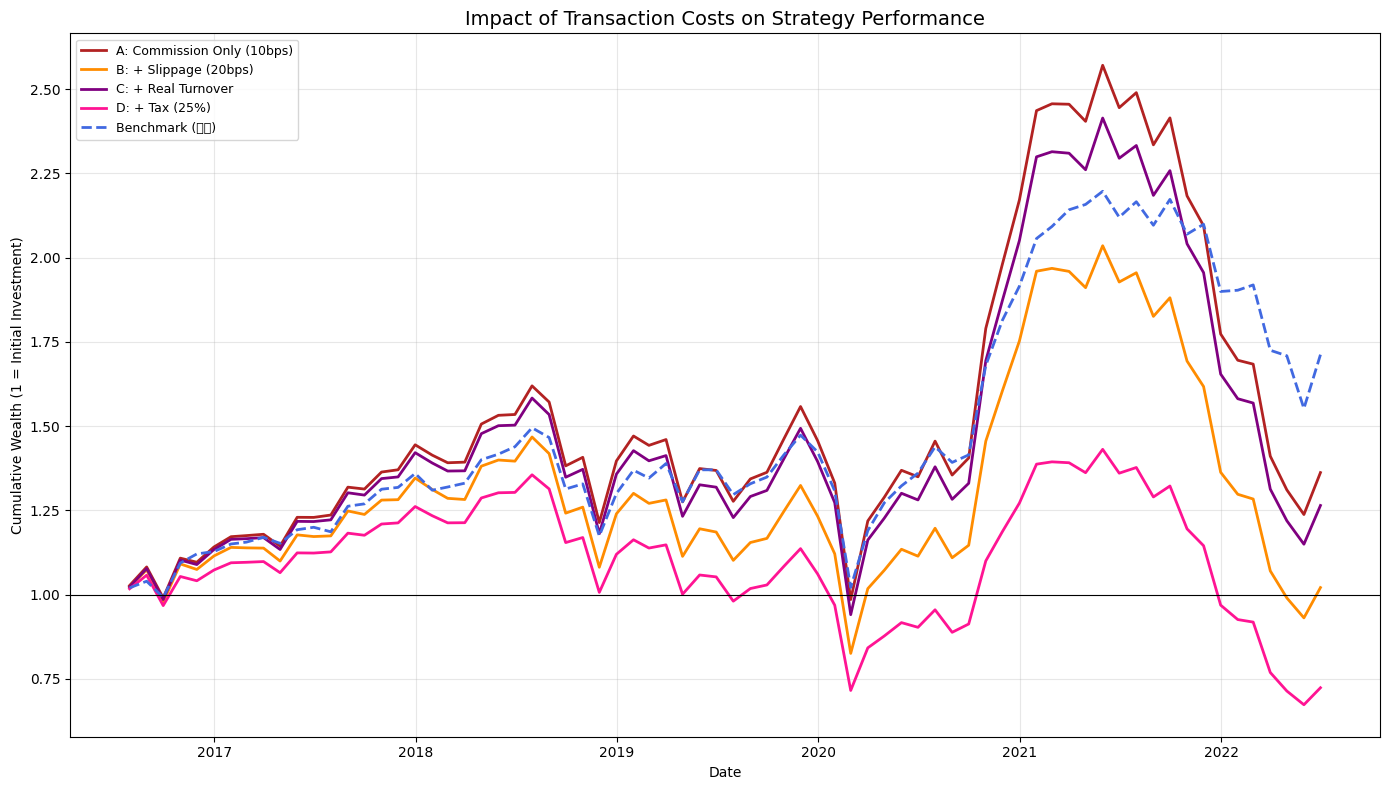

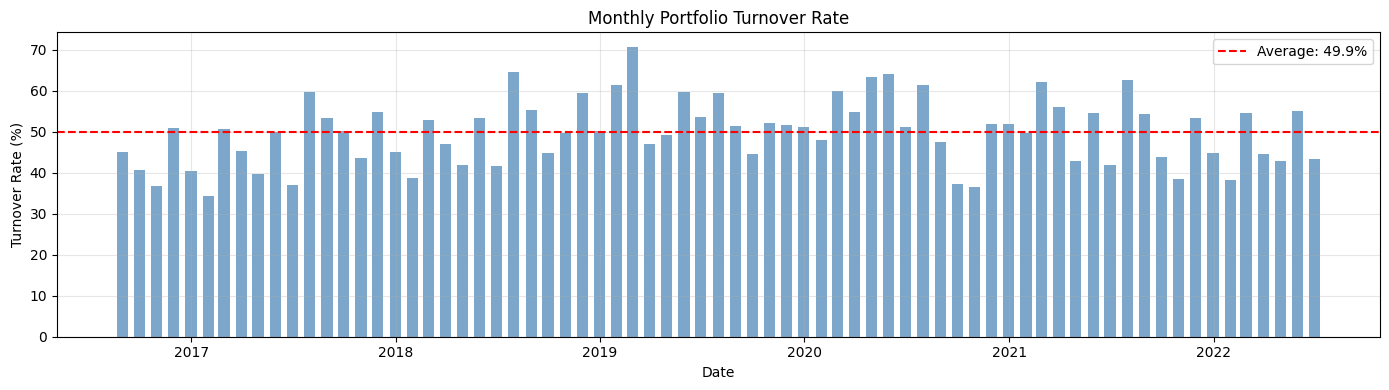

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 真实交易摩擦成本分析
# 在最优策略 (Profit-Driven) 基础上加入：
#   1. Slippage (滑点/市场冲击)
#   2. Rebalancing Turnover (换仓换手率)
#   3. Capital Gains Tax (资本利得税)
# ==========================================

print(">>> 加载最优策略预测结果...")
df_test = pd.read_csv('rf_test_predictions_sharpe_driven.csv')
df_test['public_date'] = pd.to_datetime(df_test['public_date'])

# ==========================================
# 1. 构建组合 & 计算换手率
# ==========================================
def get_decile(x):
    return pd.qcut(x, 10, labels=False, duplicates='drop') + 1

df_test['Decile'] = df_test.groupby('public_date')['rf_predict_score'].transform(get_decile)

# 获取每月 Top 10% 的股票列表
months_sorted = sorted(df_test['public_date'].unique())
monthly_holdings = {}
turnover_rates = []

for i, month in enumerate(months_sorted):
    current_top = set(df_test[(df_test['public_date'] == month) & (df_test['Decile'] == 10)]['permno'].values)
    monthly_holdings[month] = current_top
    
    if i > 0:
        prev_top = monthly_holdings[months_sorted[i-1]]
        # 换手率 = 新进入的股票数 / 组合总股票数
        new_stocks = current_top - prev_top
        turnover = len(new_stocks) / len(current_top) if len(current_top) > 0 else 0
        turnover_rates.append({'public_date': month, 'turnover_rate': turnover})

turnover_df = pd.DataFrame(turnover_rates)
avg_turnover = turnover_df['turnover_rate'].mean()
print(f">>> 平均月度单边换手率: {avg_turnover:.2%}")

# ==========================================
# 2. 计算每月策略收益
# ==========================================
long_portfolio = df_test[df_test['Decile'] == 10]
port_ret = long_portfolio.groupby('public_date')['next_month_ret'].mean().reset_index()
port_ret.rename(columns={'next_month_ret': 'Gross_Return'}, inplace=True)

# 合并换手率
port_ret = pd.merge(port_ret, turnover_df, on='public_date', how='left')
port_ret['turnover_rate'] = port_ret['turnover_rate'].fillna(1.0)  # 第一个月假设全仓建仓

# 基准收益
benchmark_ret = df_test.groupby('public_date')['next_month_ret'].mean().reset_index()
benchmark_ret.rename(columns={'next_month_ret': 'Benchmark_Return'}, inplace=True)
port_ret = pd.merge(port_ret, benchmark_ret, on='public_date')

# ==========================================
# 3. 定义各层成本参数
# ==========================================
# --- Scenario A: 原始版 (只有固定交易成本) ---
fixed_cost_bps = 10  # 单边 10bps
fixed_monthly = (fixed_cost_bps * 2) / 10000  # 双边

# --- Scenario B: + Slippage (市场冲击) ---
# 滑点通常取决于股票流动性和交易规模
# 小盘股滑点更高，大盘股更低
# 保守估计：单边 15-25bps 对机构投资者
slippage_bps = 20  # 单边 20bps

# --- Scenario C: + Rebalancing (基于真实换手率) ---
# 交易成本 = 换手率 × 单笔成本（佣金 + 滑点）
per_trade_cost_bps = 30  # 单笔成本：佣金10bps + 滑点20bps

# --- Scenario D: + Tax (短期资本利得税) ---
# 美国短期资本利得税（持有<1年）按普通收入税率
# 假设边际税率 25%（中等收入水平）
# 只对正收益部分征税
short_term_tax_rate = 0.25

# ==========================================
# 4. 计算各 Scenario 的净收益
# ==========================================

# Scenario A: 固定成本 (你原来的版本)
port_ret['Net_A'] = port_ret['Gross_Return'] - fixed_monthly

# Scenario B: 固定成本 + 滑点
total_fixed_slippage = (fixed_cost_bps + slippage_bps) * 2 / 10000
port_ret['Net_B'] = port_ret['Gross_Return'] - total_fixed_slippage

# Scenario C: 基于真实换手率的动态成本 + 滑点
# 每月成本 = 换手率 × 单笔成本(双边)
port_ret['dynamic_cost'] = port_ret['turnover_rate'] * (per_trade_cost_bps * 2) / 10000
port_ret['Net_C'] = port_ret['Gross_Return'] - port_ret['dynamic_cost']

# Scenario D: 动态成本 + 税
def apply_tax(row):
    net_before_tax = row['Net_C']
    if net_before_tax > 0:
        return net_before_tax * (1 - short_term_tax_rate)
    else:
        return net_before_tax  # 亏损不征税（简化处理）

port_ret['Net_D'] = port_ret.apply(apply_tax, axis=1)

# ==========================================
# 5. 计算累计净值 & 核心指标
# ==========================================
scenarios = {
    'A: Commission Only (10bps)': 'Net_A',
    'B: + Slippage (20bps)': 'Net_B',
    'C: + Real Turnover': 'Net_C',
    'D: + Tax (25%)': 'Net_D',
    'Benchmark (等权)': 'Benchmark_Return',
}

def calc_metrics(ret_series):
    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
    cum = (1 + ret_series).cumprod()
    max_dd = (cum / cum.cummax() - 1).min() * 100
    return ann_ret, ann_vol, sharpe, max_dd

print("\n" + "=" * 80)
print("     交易摩擦成本敏感性分析 (Sharpe-Driven 策略)")
print("=" * 80)
print(f"     假设参数: 佣金={fixed_cost_bps}bps | 滑点={slippage_bps}bps | 税率={short_term_tax_rate:.0%}")
print(f"     实际平均月度换手率: {avg_turnover:.2%}")
print("=" * 80)

results = []
for label, col in scenarios.items():
    ann_ret, ann_vol, sharpe, max_dd = calc_metrics(port_ret[col])
    results.append({
        'Scenario': label,
        'Ann_Return(%)': round(ann_ret, 2),
        'Ann_Vol(%)': round(ann_vol, 2),
        'Sharpe': round(sharpe, 2),
        'Max_DD(%)': round(max_dd, 2),
    })
    
results_df = pd.DataFrame(results)
display(results_df)

# ==========================================
# 6. 画出各 Scenario 累计净值对比图
# ==========================================
plt.figure(figsize=(14, 8))

colors = {'Net_A': 'firebrick', 'Net_B': 'darkorange', 'Net_C': 'purple', 'Net_D': 'deeppink', 'Benchmark_Return': 'royalblue'}
styles = {'Net_A': '-', 'Net_B': '-', 'Net_C': '-', 'Net_D': '-', 'Benchmark_Return': '--'}

for label, col in scenarios.items():
    cum = (1 + port_ret[col]).cumprod()
    plt.plot(port_ret['public_date'], cum, 
             label=label, color=colors[col], linestyle=styles[col], linewidth=2)

plt.axhline(1, color='black', linewidth=0.8)
plt.title('Impact of Transaction Costs on Strategy Performance', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (1 = Initial Investment)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 7. 换手率时序图
# ==========================================
plt.figure(figsize=(14, 4))
plt.bar(turnover_df['public_date'], turnover_df['turnover_rate'] * 100, 
        color='steelblue', alpha=0.7, width=20)
plt.axhline(avg_turnover * 100, color='red', linestyle='--', linewidth=1.5, 
            label=f'Average: {avg_turnover:.1%}')
plt.title('Monthly Portfolio Turnover Rate')
plt.xlabel('Date')
plt.ylabel('Turnover Rate (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

accuracy driven 

>>> 加载最优策略预测结果...
>>> 平均月度单边换手率: 17.66%

     交易摩擦成本敏感性分析 (Accuracy-Driven 策略)
     假设参数: 佣金=10bps | 滑点=20bps | 税率=25%
     实际平均月度换手率: 17.66%


,Scenario,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%)
0,A: Commission Only (10bps),11.40,35.81,0.32,-59.62
1,B: + Slippage (20bps),6.60,35.81,0.18,-61.67
2,C: + Real Turnover,12.44,35.79,0.35,-59.15
3,D: + Tax (25%),-0.32,30.55,-0.01,-59.62
4,Benchmark (等权),11.32,21.52,0.53,-31.69


/var/folders/0k/7z1g8vr51n7_n_22vk6x3zrw0000gn/T/ipykernel_59676/2638954404.py:169: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0k/7z1g8vr51n7_n_22vk6x3zrw0000gn/T/ipykernel_59676/2638954404.py:169: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/cleanml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/cleanml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


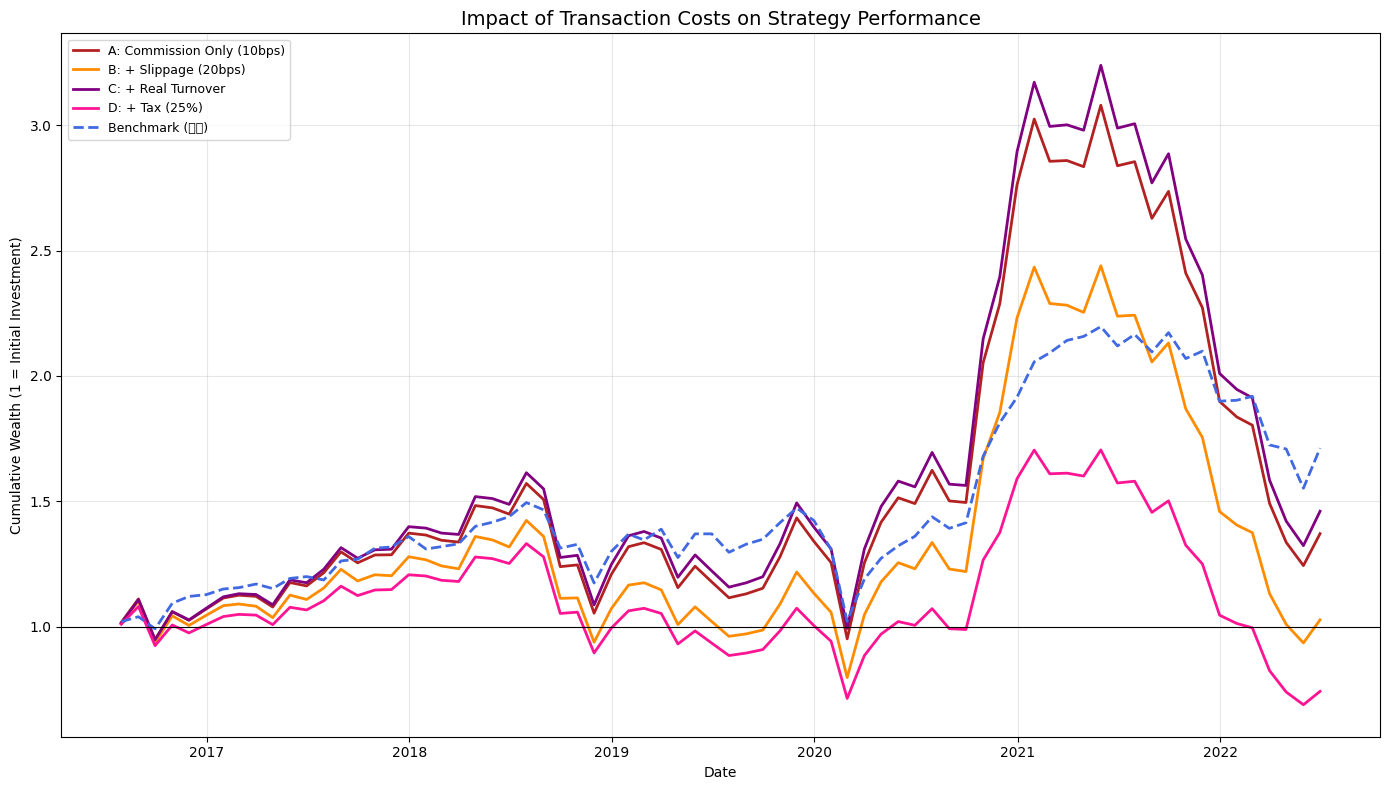

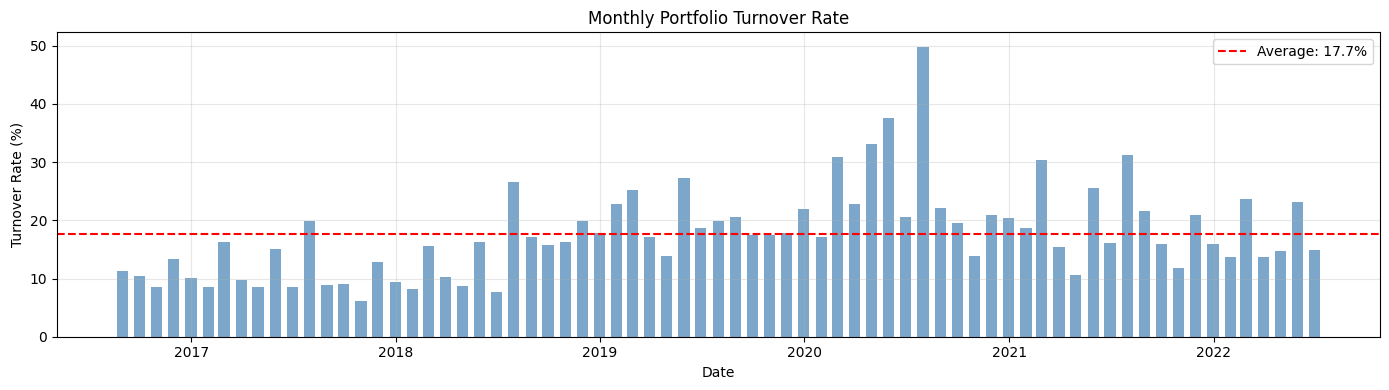

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 真实交易摩擦成本分析
# 在最优策略 (Profit-Driven) 基础上加入：
#   1. Slippage (滑点/市场冲击)
#   2. Rebalancing Turnover (换仓换手率)
#   3. Capital Gains Tax (资本利得税)
# ==========================================

print(">>> 加载最优策略预测结果...")
df_test = pd.read_csv('rf_test_predictions_classifier.csv')
df_test['public_date'] = pd.to_datetime(df_test['public_date'])

# ==========================================
# 1. 构建组合 & 计算换手率
# ==========================================
def get_decile(x):
    return pd.qcut(x, 10, labels=False, duplicates='drop') + 1

df_test['Decile'] = df_test.groupby('public_date')['rf_predict_score'].transform(get_decile)

# 获取每月 Top 10% 的股票列表
months_sorted = sorted(df_test['public_date'].unique())
monthly_holdings = {}
turnover_rates = []

for i, month in enumerate(months_sorted):
    current_top = set(df_test[(df_test['public_date'] == month) & (df_test['Decile'] == 10)]['permno'].values)
    monthly_holdings[month] = current_top
    
    if i > 0:
        prev_top = monthly_holdings[months_sorted[i-1]]
        # 换手率 = 新进入的股票数 / 组合总股票数
        new_stocks = current_top - prev_top
        turnover = len(new_stocks) / len(current_top) if len(current_top) > 0 else 0
        turnover_rates.append({'public_date': month, 'turnover_rate': turnover})

turnover_df = pd.DataFrame(turnover_rates)
avg_turnover = turnover_df['turnover_rate'].mean()
print(f">>> 平均月度单边换手率: {avg_turnover:.2%}")

# ==========================================
# 2. 计算每月策略收益
# ==========================================
long_portfolio = df_test[df_test['Decile'] == 10]
port_ret = long_portfolio.groupby('public_date')['next_month_ret'].mean().reset_index()
port_ret.rename(columns={'next_month_ret': 'Gross_Return'}, inplace=True)

# 合并换手率
port_ret = pd.merge(port_ret, turnover_df, on='public_date', how='left')
port_ret['turnover_rate'] = port_ret['turnover_rate'].fillna(1.0)  # 第一个月假设全仓建仓

# 基准收益
benchmark_ret = df_test.groupby('public_date')['next_month_ret'].mean().reset_index()
benchmark_ret.rename(columns={'next_month_ret': 'Benchmark_Return'}, inplace=True)
port_ret = pd.merge(port_ret, benchmark_ret, on='public_date')

# ==========================================
# 3. 定义各层成本参数
# ==========================================
# --- Scenario A: 原始版 (只有固定交易成本) ---
fixed_cost_bps = 10  # 单边 10bps
fixed_monthly = (fixed_cost_bps * 2) / 10000  # 双边

# --- Scenario B: + Slippage (市场冲击) ---
# 滑点通常取决于股票流动性和交易规模
# 小盘股滑点更高，大盘股更低
# 保守估计：单边 15-25bps 对机构投资者
slippage_bps = 20  # 单边 20bps

# --- Scenario C: + Rebalancing (基于真实换手率) ---
# 交易成本 = 换手率 × 单笔成本（佣金 + 滑点）
per_trade_cost_bps = 30  # 单笔成本：佣金10bps + 滑点20bps

# --- Scenario D: + Tax (短期资本利得税) ---
# 美国短期资本利得税（持有<1年）按普通收入税率
# 假设边际税率 25%（中等收入水平）
# 只对正收益部分征税
short_term_tax_rate = 0.25

# ==========================================
# 4. 计算各 Scenario 的净收益
# ==========================================

# Scenario A: 固定成本 (你原来的版本)
port_ret['Net_A'] = port_ret['Gross_Return'] - fixed_monthly

# Scenario B: 固定成本 + 滑点
total_fixed_slippage = (fixed_cost_bps + slippage_bps) * 2 / 10000
port_ret['Net_B'] = port_ret['Gross_Return'] - total_fixed_slippage

# Scenario C: 基于真实换手率的动态成本 + 滑点
# 每月成本 = 换手率 × 单笔成本(双边)
port_ret['dynamic_cost'] = port_ret['turnover_rate'] * (per_trade_cost_bps * 2) / 10000
port_ret['Net_C'] = port_ret['Gross_Return'] - port_ret['dynamic_cost']

# Scenario D: 动态成本 + 税
def apply_tax(row):
    net_before_tax = row['Net_C']
    if net_before_tax > 0:
        return net_before_tax * (1 - short_term_tax_rate)
    else:
        return net_before_tax  # 亏损不征税（简化处理）

port_ret['Net_D'] = port_ret.apply(apply_tax, axis=1)

# ==========================================
# 5. 计算累计净值 & 核心指标
# ==========================================
scenarios = {
    'A: Commission Only (10bps)': 'Net_A',
    'B: + Slippage (20bps)': 'Net_B',
    'C: + Real Turnover': 'Net_C',
    'D: + Tax (25%)': 'Net_D',
    'Benchmark (等权)': 'Benchmark_Return',
}

def calc_metrics(ret_series):
    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
    cum = (1 + ret_series).cumprod()
    max_dd = (cum / cum.cummax() - 1).min() * 100
    return ann_ret, ann_vol, sharpe, max_dd

print("\n" + "=" * 80)
print("     交易摩擦成本敏感性分析 (Accuracy-Driven 策略)")
print("=" * 80)
print(f"     假设参数: 佣金={fixed_cost_bps}bps | 滑点={slippage_bps}bps | 税率={short_term_tax_rate:.0%}")
print(f"     实际平均月度换手率: {avg_turnover:.2%}")
print("=" * 80)

results = []
for label, col in scenarios.items():
    ann_ret, ann_vol, sharpe, max_dd = calc_metrics(port_ret[col])
    results.append({
        'Scenario': label,
        'Ann_Return(%)': round(ann_ret, 2),
        'Ann_Vol(%)': round(ann_vol, 2),
        'Sharpe': round(sharpe, 2),
        'Max_DD(%)': round(max_dd, 2),
    })
    
results_df = pd.DataFrame(results)
display(results_df)

# ==========================================
# 6. 画出各 Scenario 累计净值对比图
# ==========================================
plt.figure(figsize=(14, 8))

colors = {'Net_A': 'firebrick', 'Net_B': 'darkorange', 'Net_C': 'purple', 'Net_D': 'deeppink', 'Benchmark_Return': 'royalblue'}
styles = {'Net_A': '-', 'Net_B': '-', 'Net_C': '-', 'Net_D': '-', 'Benchmark_Return': '--'}

for label, col in scenarios.items():
    cum = (1 + port_ret[col]).cumprod()
    plt.plot(port_ret['public_date'], cum, 
             label=label, color=colors[col], linestyle=styles[col], linewidth=2)

plt.axhline(1, color='black', linewidth=0.8)
plt.title('Impact of Transaction Costs on Strategy Performance', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (1 = Initial Investment)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 7. 换手率时序图
# ==========================================
plt.figure(figsize=(14, 4))
plt.bar(turnover_df['public_date'], turnover_df['turnover_rate'] * 100, 
        color='steelblue', alpha=0.7, width=20)
plt.axhline(avg_turnover * 100, color='red', linestyle='--', linewidth=1.5, 
            label=f'Average: {avg_turnover:.1%}')
plt.title('Monthly Portfolio Turnover Rate')
plt.xlabel('Date')
plt.ylabel('Turnover Rate (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()